# Final Assessment: Cat Detection v2

This notebook continues my Week-1 cat detection project and prepares the improved detector for the final Unit 6 assessment.

The goal of this assessment is not only to train a better YOLO26 cat detector, but also to prepare a reproducible model that can later be exported to ONNX and used inside a Docker container.

In Week 1, my YOLO26n model detected cats well, but the failure cases showed that it could also produce false positives on non-cat images. In this notebook, I rebuild the hard-negative dataset, compare the Week-1 and improved checkpoints, and prepare the next improved training run.

## Notebook Plan

This notebook is organized in the same order as the assessment requirements:

1. Check and rebuild the final dataset.
2. Add hard negative images with empty YOLO labels.
3. Recreate train/validation/test split files.
4. Recap the Week-1 result and weaknesses.
5. Compare the saved Week-1 and improved model checkpoints.
6. Train a stronger candidate model for the final assessment.
7. Select the best model for ONNX export and deployment.

## Global Setup

I define the main paths and reusable configuration values here.

The most important dataset folder is `data/DATA_CLEAN_LAST`. After the hard-negative rebuild, this folder should contain both the original cat images and the added non-cat negative images.

In [1]:
from pathlib import Path
import random
import shutil
import pandas as pd

DATA_DIR = Path("data/DATA_CLEAN_LAST")
IMAGE_DIR = DATA_DIR / "images"
LABEL_DIR = DATA_DIR / "labels"

DOG_RAW_DIR = Path("data/images")
MIXED_RAW_DIR = Path("data/mixed_negatives_raw")

image_extensions = [".jpg", ".jpeg", ".png", ".webp"]

SEED = 42
random.seed(SEED)

print("DATA_DIR:", DATA_DIR.resolve())
print("IMAGE_DIR exists:", IMAGE_DIR.exists())
print("LABEL_DIR exists:", LABEL_DIR.exists())

DATA_DIR: C:\Users\user\Documents\IronHack_Labs\m6-09-assessment\data\DATA_CLEAN_LAST
IMAGE_DIR exists: True
LABEL_DIR exists: True


## Checking the Current Dataset State

Before making any changes, I check the current state of `DATA_CLEAN_LAST`.

This is important because this folder may initially contain only the cleaned Week-1 cat dataset. The final improved dataset should later contain 3442 cat images and 1000 hard negative images.

In [2]:
all_images = [
    p for p in IMAGE_DIR.iterdir()
    if p.is_file() and p.suffix.lower() in image_extensions
]

all_labels = list(LABEL_DIR.glob("*.txt"))

empty_labels = [
    p for p in all_labels
    if p.read_text().strip() == ""
]

print("Total images:", len(all_images))
print("Total labels:", len(all_labels))
print("Empty negative labels:", len(empty_labels))
print("Non-empty cat labels:", len(all_labels) - len(empty_labels))

for split_name in ["train.txt", "val.txt", "test.txt"]:
    split_path = DATA_DIR / split_name
    print("\n", split_name, "exists:", split_path.exists())
    if split_path.exists():
        lines = [line.strip() for line in split_path.read_text().splitlines() if line.strip()]
        print(split_name, "count:", len(lines))

Total images: 3442
Total labels: 3442
Empty negative labels: 0
Non-empty cat labels: 3442

 train.txt exists: True
train.txt count: 2409

 val.txt exists: True
val.txt count: 516

 test.txt exists: True
test.txt count: 517


## Checking Required Files from Week 1

I verify that the important files from the previous assessment are available.

The saved checkpoints are needed for comparison. The final improved checkpoint is also the model that will later be exported to ONNX unless a new training run performs better.

In [3]:
check_paths = {
    "DATA_CLEAN_LAST": Path("data/DATA_CLEAN_LAST"),
    "data_v2.yaml": Path("data_v2.yaml"),
    "v1 best.pt": Path("runs/cats_v1/weights/best.pt"),
    "v2 best.pt": Path("runs/cats_v2_hardneg/weights/best.pt"),
    "v3 best.pt": Path("runs/cats_v3_hardneg_low_lr/weights/best.pt"),
    "final_model best.pt": Path("final_model/best.pt"),
}

for name, path in check_paths.items():
    print(f"{name}: {path.exists()} -> {path}")

DATA_CLEAN_LAST: True -> data\DATA_CLEAN_LAST
data_v2.yaml: True -> data_v2.yaml
v1 best.pt: True -> runs\cats_v1\weights\best.pt
v2 best.pt: True -> runs\cats_v2_hardneg\weights\best.pt
v3 best.pt: True -> runs\cats_v3_hardneg_low_lr\weights\best.pt
final_model best.pt: True -> final_model\best.pt


## Checking Hard Negative Source Folders

The Week-1 model often confused non-cat objects with cats. To reduce this weakness, I use hard negative images.

The folder `data/images` contains Oxford Pet images. I use only known dog breeds from this folder as dog hard negatives. The folder `data/mixed_negatives_raw` contains additional non-cat images such as humans, toys, rooms, and other animals.

Using these two sources allows the model to learn that many visually similar or distracting objects are not cats.

In [4]:
print("Dog/raw images folder exists:", DOG_RAW_DIR.exists())
print("Mixed negatives folder exists:", MIXED_RAW_DIR.exists())

if DOG_RAW_DIR.exists():
    dog_raw_files = [
        p for p in DOG_RAW_DIR.rglob("*")
        if p.is_file() and p.suffix.lower() in image_extensions
    ]
    print("Raw image files in data/images:", len(dog_raw_files))
    print("Examples:", [p.name for p in dog_raw_files[:10]])

if MIXED_RAW_DIR.exists():
    mixed_raw_files = [
        p for p in MIXED_RAW_DIR.rglob("*")
        if p.is_file() and p.suffix.lower() in image_extensions
    ]
    print("Raw mixed negative files:", len(mixed_raw_files))
    print("Examples:", [p.name for p in mixed_raw_files[:10]])

Dog/raw images folder exists: True
Mixed negatives folder exists: True
Raw image files in data/images: 7390
Examples: ['Abyssinian_1.jpg', 'Abyssinian_10.jpg', 'Abyssinian_100.jpg', 'Abyssinian_101.jpg', 'Abyssinian_102.jpg', 'Abyssinian_103.jpg', 'Abyssinian_104.jpg', 'Abyssinian_105.jpg', 'Abyssinian_106.jpg', 'Abyssinian_107.jpg']
Raw mixed negative files: 500
Examples: ['animal_0000.jpg', 'animal_0001.jpg', 'animal_0002.jpg', 'animal_0003.jpg', 'animal_0004.jpg', 'animal_0005.jpg', 'animal_0006.jpg', 'animal_0007.jpg', 'animal_0008.jpg', 'animal_0009.jpg']


## Adding Hard Negative Images

I add 1000 hard negative images to the cleaned cat dataset:

- 500 dog images from the Oxford Pet image folder
- 500 mixed non-cat images from `mixed_negatives_raw`

For every hard negative image, I create a matching empty `.txt` label file. In YOLO format, an empty label file means that the image contains no target object.

The task remains single-class object detection, so the only object class is still `cat`. These negative examples are added only to teach the detector when not to predict a cat.

### Dog Selection Strategy

To avoid accidentally adding cat images as negative examples, I do not simply take every non-cat-looking file.

Instead, I explicitly filter the Oxford Pet images using known dog breed names. This makes the dog-negative set safer and easier to explain in the documentation.

In [5]:
# Fixed list of Oxford-IIIT Pet dog breed prefixes.
dog_breeds = [
    "american_bulldog",
    "american_pit_bull_terrier",
    "basset_hound",
    "beagle",
    "boxer",
    "chihuahua",
    "english_cocker_spaniel",
    "english_setter",
    "german_shorthaired",
    "great_pyrenees",
    "havanese",
    "japanese_chin",
    "keeshond",
    "leonberger",
    "miniature_pinscher",
    "newfoundland",
    "pomeranian",
    "pug",
    "saint_bernard",
    "samoyed",
    "scottish_terrier",
    "shiba_inu",
    "staffordshire_bull_terrier",
    "wheaten_terrier",
    "yorkshire_terrier",
]

def is_dog_oxford_image(path: Path) -> bool:
    stem_lower = path.stem.lower()
    return any(stem_lower.startswith(breed) for breed in dog_breeds)

# Remove existing hard-negative copies first, so this cell is reproducible.
for pattern in ["neg_dog_*", "neg_mixed_*"]:
    for p in IMAGE_DIR.glob(pattern):
        if p.is_file():
            p.unlink()
    for p in LABEL_DIR.glob(pattern + ".txt"):
        if p.is_file():
            p.unlink()

print("Existing neg_dog_* and neg_mixed_* files removed from DATA_CLEAN_LAST.")

Existing neg_dog_* and neg_mixed_* files removed from DATA_CLEAN_LAST.


In [6]:
random.seed(SEED)

IMAGE_DIR.mkdir(parents=True, exist_ok=True)
LABEL_DIR.mkdir(parents=True, exist_ok=True)

# 1) Dog hard negatives from Oxford Pet images
all_raw_images = [
    p for p in DOG_RAW_DIR.rglob("*")
    if p.is_file() and p.suffix.lower() in image_extensions
]

dog_candidates = [
    p for p in all_raw_images
    if is_dog_oxford_image(p)
]

random.shuffle(dog_candidates)
selected_dogs = dog_candidates[:500]

print("Dog candidates:", len(dog_candidates))
print("Selected dog negatives:", len(selected_dogs))
print("Dog examples:", [p.name for p in selected_dogs[:10]])

for i, src in enumerate(selected_dogs):
    new_stem = f"neg_dog_{i:04d}"
    dst_img = IMAGE_DIR / f"{new_stem}{src.suffix.lower()}"
    dst_label = LABEL_DIR / f"{new_stem}.txt"

    shutil.copy2(src, dst_img)
    dst_label.write_text("")

# 2) Mixed hard negatives
mixed_candidates = [
    p for p in MIXED_RAW_DIR.rglob("*")
    if p.is_file() and p.suffix.lower() in image_extensions
]

random.shuffle(mixed_candidates)
selected_mixed = mixed_candidates[:500]

print("Mixed candidates:", len(mixed_candidates))
print("Selected mixed negatives:", len(selected_mixed))
print("Mixed examples:", [p.name for p in selected_mixed[:10]])

for i, src in enumerate(selected_mixed):
    new_stem = f"neg_mixed_{i:04d}"
    dst_img = IMAGE_DIR / f"{new_stem}{src.suffix.lower()}"
    dst_label = LABEL_DIR / f"{new_stem}.txt"

    shutil.copy2(src, dst_img)
    dst_label.write_text("")

print("Hard negative images added.")

Dog candidates: 4990
Selected dog negatives: 500
Dog examples: ['english_cocker_spaniel_169.jpg', 'wheaten_terrier_14.jpg', 'samoyed_140.jpg', 'english_cocker_spaniel_12.jpg', 'great_pyrenees_187.jpg', 'german_shorthaired_174.jpg', 'basset_hound_93.jpg', 'chihuahua_95.jpg', 'basset_hound_95.jpg', 'chihuahua_90.jpg']
Mixed candidates: 500
Selected mixed negatives: 500
Mixed examples: ['toy_0014.jpg', 'human_0145.jpg', 'animal_0025.jpg', 'toy_0095.jpg', 'room_0020.jpg', 'human_0021.jpg', 'toy_0104.jpg', 'human_0047.jpg', 'animal_0041.jpg', 'toy_0146.jpg']
Hard negative images added.


## Verifying the Final Hard Negative Dataset

After adding the hard negatives, I verify that every image has a matching label file.

The expected final dataset size is:

- 3442 cat images with normal YOLO labels
- 1000 hard negative images with empty labels
- 4442 total images

In [7]:
all_images = [
    p for p in IMAGE_DIR.iterdir()
    if p.is_file() and p.suffix.lower() in image_extensions
]

all_labels = list(LABEL_DIR.glob("*.txt"))

empty_labels = [
    p for p in all_labels
    if p.read_text().strip() == ""
]

image_stems = {p.stem for p in all_images}
label_stems = {p.stem for p in all_labels}

images_without_labels = sorted(image_stems - label_stems)
labels_without_images = sorted(label_stems - image_stems)

print("Total images:", len(all_images))
print("Total labels:", len(all_labels))
print("Empty negative labels:", len(empty_labels))
print("Non-empty cat labels:", len(all_labels) - len(empty_labels))
print("Images without labels:", len(images_without_labels))
print("Labels without images:", len(labels_without_images))

Total images: 4442
Total labels: 4442
Empty negative labels: 1000
Non-empty cat labels: 3442
Images without labels: 0
Labels without images: 0


## Rebuilding Train/Validation/Test Splits

After the hard negatives are restored, I rebuild the split files.

I use a fixed random seed so the split is reproducible. The split ratio is approximately 70% training, 15% validation, and 15% testing.

In [8]:
random.seed(SEED)

all_image_paths = sorted(all_images)
random.shuffle(all_image_paths)

n_total = len(all_image_paths)
n_train = int(n_total * 0.70)
n_val = int(n_total * 0.15)
n_test = n_total - n_train - n_val

train_images = all_image_paths[:n_train]
val_images = all_image_paths[n_train:n_train + n_val]
test_images = all_image_paths[n_train + n_val:]

def write_split_file(image_list, output_file):
    with open(output_file, "w") as f:
        for img_path in image_list:
            f.write(img_path.resolve().as_posix() + "\n")

write_split_file(train_images, DATA_DIR / "train.txt")
write_split_file(val_images, DATA_DIR / "val.txt")
write_split_file(test_images, DATA_DIR / "test.txt")

print("Train:", len(train_images))
print("Val:", len(val_images))
print("Test:", len(test_images))
print("Total:", len(train_images) + len(val_images) + len(test_images))

Train: 3109
Val: 666
Test: 667
Total: 4442


## Checking Negative Images Inside Each Split

I also verify that the hard negative images are distributed across the train, validation, and test splits.

This matters because the final model should be evaluated not only on cat images, but also on whether it avoids false positives on non-cat images.

In [9]:
def is_negative_image(img_path):
    label_path = LABEL_DIR / f"{img_path.stem}.txt"
    return label_path.exists() and label_path.read_text().strip() == ""

train_negatives = [p for p in train_images if is_negative_image(p)]
val_negatives = [p for p in val_images if is_negative_image(p)]
test_negatives = [p for p in test_images if is_negative_image(p)]

print("Train negative images:", len(train_negatives))
print("Val negative images:", len(val_negatives))
print("Test negative images:", len(test_negatives))
print("Total negative images in splits:", len(train_negatives) + len(val_negatives) + len(test_negatives))

Train negative images: 735
Val negative images: 130
Test negative images: 135
Total negative images in splits: 1000


## Creating the Dataset Configuration File

The file `data_v2.yaml` points YOLO26 to the final hard-negative dataset.

The class mapping stays simple because this is still a single-class detector. The only class is `cat`.

In [10]:
data_v2_content = """path: ./data/DATA_CLEAN_LAST
train: train.txt
val: val.txt
test: test.txt

names:
  0: cat
"""

Path("data_v2.yaml").write_text(data_v2_content)
print(Path("data_v2.yaml").read_text())

path: ./data/DATA_CLEAN_LAST
train: train.txt
val: val.txt
test: test.txt

names:
  0: cat



# Week-1 Recap

In Week 1, I trained a YOLO26n cat detector on the cleaned cat dataset.

The best validation metrics from the Week-1 training run were:

- Validation mAP@0.5: 0.9287
- Validation mAP@0.5:0.95: 0.7324
- Precision: 0.9233
- Recall: 0.8772

The model performed well on many cat images, but the failure analysis showed two important weaknesses:

1. The model produced many false positives on non-cat images, especially dogs and other animal-like objects.
2. Some difficult cat images had weaker confidence or localization when the cat was small, partially visible, or in a cluttered scene.

Because of these weaknesses, the main improvement goal for the final assessment is to make the detector more reliable in real-world inference, not only to increase mAP.

# Improvement Strategy

I use the following Week-2 improvement techniques:

1. More data discipline with hard negatives  
   I add 1000 non-cat images with empty labels. This directly targets the false-positive problem from Week 1.

2. Transfer learning from the Week-1 checkpoint  
   Instead of training from scratch, the improved model is fine-tuned from the Week-1 model so it keeps its existing cat-detection ability.

3. Lower learning-rate fine-tuning with AdamW and early stopping  
   The first hard-negative fine-tuning run reduced false positives but hurt recall and mAP. I improved this by using a lower learning rate, AdamW, and early stopping.

4. New candidate model for this assessment  
   I also prepare a stronger candidate run using a larger YOLO26 variant, stronger augmentation, and a cosine learning-rate schedule. This gives me a fair chance to improve beyond the previous v3 checkpoint.

## Saved Checkpoints Used for Comparison

The repository already contains three saved checkpoints from the previous work:

- `cats_v1`: Week-1 baseline model
- `cats_v2_hardneg`: first hard-negative fine-tuning run
- `cats_v3_hardneg_low_lr`: improved hard-negative fine-tuning run

I load these models and compare them before deciding whether the new training run improves the final result.

In [19]:
from ultralytics import YOLO

model_paths = {
    "v1_original": Path("runs/cats_v1/weights/best.pt"),
    "v2_hardneg": Path("runs/cats_v2_hardneg/weights/best.pt"),
    "v3_hardneg_low_lr": Path("runs/cats_v3_hardneg_low_lr/weights/best.pt"),
}

for name, path in model_paths.items():
    print(name, "exists:", path.exists(), "->", path)

v1_model = YOLO(str(model_paths["v1_original"]))
v2_model = YOLO(str(model_paths["v2_hardneg"]))
v3_model = YOLO(str(model_paths["v3_hardneg_low_lr"]))

v1_original exists: True -> runs\cats_v1\weights\best.pt
v2_hardneg exists: True -> runs\cats_v2_hardneg\weights\best.pt
v3_hardneg_low_lr exists: True -> runs\cats_v3_hardneg_low_lr\weights\best.pt


## Baseline and Improved Model Comparison

The table below recomputes the main test metrics directly from the saved checkpoints using the current `data_v2.yaml` test split.

This avoids manually typed results and makes the comparison reproducible.

I compare three saved checkpoints:

1. `cats_v1` — the Week-1 baseline model trained on the original cleaned cat dataset.
2. `cats_v2_hardneg` — the first hard-negative fine-tuning attempt.
3. `cats_v3_hardneg_low_lr` — the improved hard-negative fine-tuning run with AdamW, lower learning rate, and early stopping.

The goal of this comparison is to decide which saved checkpoint is the strongest before training the final candidate model.

In [20]:
from ultralytics import YOLO
import pandas as pd
from pathlib import Path

models_to_compare = [
    {
        "Run": "Week-1 baseline",
        "Backbone": "yolo26n",
        "Tricks": "Original cleaned cat dataset",
        "Path": "runs/cats_v1/weights/best.pt",
    },
    {
        "Run": "v2_hardneg",
        "Backbone": "yolo26n",
        "Tricks": "Hard negatives + fine-tuning",
        "Path": "runs/cats_v2_hardneg/weights/best.pt",
    },
    {
        "Run": "v3_hardneg_low_lr",
        "Backbone": "yolo26n",
        "Tricks": "Hard negatives + AdamW + low LR + early stopping",
        "Path": "runs/cats_v3_hardneg_low_lr/weights/best.pt",
    },
]

comparison_rows = []

for item in models_to_compare:
    model_path = Path(item["Path"])

    print(f"Evaluating: {item['Run']}")
    print("Checkpoint exists:", model_path.exists())

    if not model_path.exists():
        raise FileNotFoundError(f"Missing checkpoint: {model_path}")

    model = YOLO(str(model_path))

    metrics = model.val(
        data="data_v2.yaml",
        split="test",
        imgsz=640,
        device=0,
        workers=0
    )

    comparison_rows.append({
        "Run": item["Run"],
        "Backbone": item["Backbone"],
        "Tricks": item["Tricks"],
        "mAP@0.5": metrics.box.map50,
        "mAP@0.5:0.95": metrics.box.map,
        "P": metrics.box.mp,
        "R": metrics.box.mr,
    })

comparison_df = pd.DataFrame(comparison_rows)
comparison_df

Evaluating: Week-1 baseline
Checkpoint exists: True
Ultralytics 8.4.50  Python-3.13.0 torch-2.12.0+cu126 CUDA:0 (NVIDIA GeForce RTX 2050, 4096MiB)
YOLO26n summary (fused): 122 layers, 2,375,031 parameters, 0 gradients, 5.2 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 1201.2729.0 MB/s, size: 1440.9 KB)
val: Scanning C:\Users\user\Documents\IronHack_Labs\m6-09-assessment\data\DATA_CLEAN_LAST\labels.cache... 667 images, 135 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 667/667 254.3Mit/s 0.0s
val: C:\Users\user\Documents\IronHack_Labs\m6-09-assessment\data\DATA_CLEAN_LAST\images\neg_mixed_0311.jpg: corrupt JPEG restored and saved
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 42/42 1.4it/s 30.5s0.8ss
                   all        667        621      0.809      0.882      0.877      0.714
Speed: 0.6ms preprocess, 12.3ms inference, 0.0ms loss, 0.1ms postprocess per image
Results saved to C:\Users\user\Documents\IronHack_Labs

,Run,Backbone,Tricks,mAP@0.5,mAP@0.5:0.95,P,R
0,Week-1 baseline,yolo26n,Original cleaned cat dataset,0.876840,0.714009,0.809131,0.882448
1,v2_hardneg,yolo26n,Hard negatives + fine-tuning,0.877028,0.632933,0.843523,0.813205
2,v3_hardneg_low_lr,yolo26n,Hard negatives + AdamW + low LR + early stopping,0.935942,0.744799,0.915468,0.871963


## Model Comparison Interpretation

The checkpoint-based test evaluation confirms that `v3_hardneg_low_lr` is the strongest saved model so far.

The Week-1 baseline has strong recall, but its precision is lower. This matches the failure analysis from Week 1: the model detects many cats, but it also produces more false positives on non-cat images.

The `v2_hardneg` model improves precision slightly, but its recall and mAP@0.5:0.95 drop. This shows that adding hard negatives helped reduce false positives, but the first fine-tuning setup was too aggressive and hurt localization quality.

The `v3_hardneg_low_lr` model gives the best overall balance. It has the highest mAP@0.5, highest mAP@0.5:0.95, and highest precision while keeping recall close to the baseline.

Because these metrics are recomputed from the saved checkpoints, small differences from earlier recorded values are expected if the dataset split or cache was rebuilt.

## False Positive Comparison on Hard Negative Test Images

Since one of the main Week-1 weaknesses was false positives, I also evaluate the saved checkpoints on negative test images.

These are images with empty YOLO label files, which means they do not contain cats. If the model predicts a cat on one of these images, I count it as a false positive.

This section recomputes the false-positive results directly from the saved checkpoints and the current `data_v2.yaml` test split. This makes the comparison reproducible and avoids relying on manually typed numbers.

In [21]:
def get_negative_test_images():
    test_txt_path = DATA_DIR / "test.txt"

    with open(test_txt_path, "r") as f:
        test_image_paths = [
            Path(line.strip())
            for line in f
            if line.strip()
        ]

    negative_test_images = []

    for img_path in test_image_paths:
        label_path = LABEL_DIR / f"{img_path.stem}.txt"

        if label_path.exists() and label_path.read_text().strip() == "":
            negative_test_images.append(img_path)

    return test_image_paths, negative_test_images


test_image_paths, negative_test_images = get_negative_test_images()

print("Total test images:", len(test_image_paths))
print("Negative test images:", len(negative_test_images))
print("Examples:", [p.name for p in negative_test_images[:10]])

Total test images: 667
Negative test images: 135
Examples: ['neg_dog_0324.jpg', 'neg_dog_0000.jpg', 'neg_mixed_0401.jpg', 'neg_dog_0235.jpg', 'neg_mixed_0440.jpg', 'neg_dog_0210.jpg', 'neg_dog_0053.jpg', 'neg_mixed_0300.jpg', 'neg_dog_0165.jpg', 'neg_mixed_0410.jpg']


In [22]:
def false_positive_rate_on_negatives(model, image_paths, conf=0.25):
    false_positive_count = 0
    max_confidences = []

    for img_path in image_paths:
        results = model.predict(
            source=str(img_path),
            conf=conf,
            device=0,
            verbose=False
        )

        boxes = results[0].boxes

        if len(boxes) > 0:
            false_positive_count += 1
            max_conf = max(float(box.conf[0]) for box in boxes)
            max_confidences.append(max_conf)
        else:
            max_confidences.append(0.0)

    total = len(image_paths)

    return {
        "total_negative_images": total,
        "false_positive_count": false_positive_count,
        "false_positive_rate": false_positive_count / total if total else 0,
        "avg_max_confidence": sum(max_confidences) / total if total else 0,
        "max_confidence": max(max_confidences) if max_confidences else 0,
    }

In [23]:
fp_models_to_compare = [
    {
        "model": "v1_original",
        "checkpoint": "runs/cats_v1/weights/best.pt",
    },
    {
        "model": "v3_hardneg_low_lr",
        "checkpoint": "runs/cats_v3_hardneg_low_lr/weights/best.pt",
    },
]

fp_rows = []

for item in fp_models_to_compare:
    print(f"Evaluating false positives: {item['model']}")

    checkpoint_path = Path(item["checkpoint"])

    if not checkpoint_path.exists():
        raise FileNotFoundError(f"Missing checkpoint: {checkpoint_path}")

    model = YOLO(str(checkpoint_path))

    fp_result = false_positive_rate_on_negatives(
        model=model,
        image_paths=negative_test_images,
        conf=0.25
    )

    fp_rows.append({
        "model": item["model"],
        **fp_result,
    })

fp_comparison_df = pd.DataFrame(fp_rows)
fp_comparison_df

Evaluating false positives: v1_original
Evaluating false positives: v3_hardneg_low_lr


,model,total_negative_images,false_positive_count,false_positive_rate,avg_max_confidence,max_confidence
0,v1_original,135,113,0.837037,0.595882,0.960885
1,v3_hardneg_low_lr,135,13,0.096296,0.046567,0.820569


## False Positive Result Interpretation

The false-positive evaluation confirms the main improvement from the hard-negative fine-tuning process.

The Week-1 baseline still predicts cats on many negative images, which matches the original failure analysis. The `v3_hardneg_low_lr` checkpoint makes far fewer false-positive predictions on the same negative test images.

The exact false-positive numbers may differ slightly from earlier experiments because this notebook recomputes the result from the current rebuilt test split. However, the conclusion is unchanged: `v3_hardneg_low_lr` is much more reliable on non-cat images than the Week-1 baseline.

## Current Best Saved Model

Based on the checkpoint-based test metrics and the recomputed false-positive evaluation, the strongest saved model is `cats_v3_hardneg_low_lr`.

This checkpoint has the best overall mAP and precision among the saved models, while keeping recall close to the Week-1 baseline. It also greatly reduces false positives on hard negative images.

For this reason, I keep `cats_v3_hardneg_low_lr` as the current best saved checkpoint. The next step is to train one final candidate model and compare it against this v3 checkpoint before deciding which model to export to ONNX and deploy.

## Additional Candidate Models: v4, v5, and v6

After the Week-1 baseline and the first improved checkpoints, I trained three additional candidate models. The purpose was to avoid selecting a final model from only one experiment.

| Run | Starting point | Main idea |
|---|---|---|
| `v3_hardneg_low_lr` | Week-1 cat checkpoint | Hard negatives + low learning rate + AdamW |
| `v4_yolo26s_aug_coslr` | `yolo26s.pt` | Larger backbone + stronger augmentation + cosine LR |
| `v5_yolo26n_60epochs_low_lr` | `yolo26n.pt` | Fresh YOLO26n long training with low LR + cosine LR |
| `v6_v3_recipe_60epochs` | Week-1 cat checkpoint | Extended version of the successful v3 recipe |

The final model is not selected only from validation logs. All available checkpoints are evaluated on the same held-out test split, then compared using test mAP, precision, recall, false-positive behavior, and deployment practicality.

For deployment, a smaller YOLO26n model is preferred if it performs similarly to a larger YOLO26s model, because it is faster, lighter, and easier to containerize.


### v4 Training: Larger YOLO26s Candidate

This run tests whether a larger YOLO26s model can outperform the smaller YOLO26n checkpoints.

The model uses `yolo26s.pt`, stronger augmentation, AdamW, cosine learning-rate scheduling, weight decay, and early stopping.

This training cell is kept for reproducibility. Since the model has already been trained, the run flag is set to `False` by default.


In [24]:
RUN_V4_TRAINING = True

if RUN_V4_TRAINING:
    v4_model = YOLO("yolo26s.pt")

    v4_results = v4_model.train(
        data="data_v2.yaml",
        epochs=60,
        imgsz=640,
        batch=2,
        device=0,
        workers=0,
        project="runs",
        name="cats_v4_yolo26s_aug_coslr",
        seed=42,
        optimizer="AdamW",
        lr0=0.0005,
        lrf=0.01,
        cos_lr=True,
        patience=10,
        weight_decay=0.0005,
        mosaic=0.8,
        mixup=0.1,
        hsv_h=0.015,
        hsv_s=0.7,
        hsv_v=0.4,
        translate=0.1,
        scale=0.5,
        fliplr=0.5,
        cache=False,
        exist_ok=True
    )
else:
    print("V4 training skipped. Set RUN_V4_TRAINING=True when ready to train the new candidate model.")

New https://pypi.org/project/ultralytics/8.4.54 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.50  Python-3.13.0 torch-2.12.0+cu126 CUDA:0 (NVIDIA GeForce RTX 2050, 4096MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=2, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=data_v2.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=60, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0005, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolo26s.pt, momentum=0.937, mosaic=0.8, multi_scale=0.0, name=cats_v4_yol

### v5 Training: Fresh YOLO26n Long-Training Candidate

This run starts from the pretrained `yolo26n.pt` model instead of the earlier v1 or v3 checkpoint.

The goal is to test whether a clean YOLO26n run trained for longer can outperform the earlier v3 model. The training setup keeps the successful low-learning-rate idea but adds cosine learning-rate scheduling.

This training cell is kept for reproducibility. Since the model has already been trained, the run flag is set to `False` by default.


In [25]:
from ultralytics import YOLO

RUN_V5_TRAINING = True

if RUN_V5_TRAINING:
    v5_model = YOLO("yolo26n.pt")

    v5_results = v5_model.train(
        data="data_v2.yaml",
        epochs=60,
        imgsz=640,
        batch=4,
        project="runs",
        name="cats_v5_yolo26n_60epochs_low_lr",
        seed=42,
        device=0,
        workers=0,
        patience=15,
        optimizer="AdamW",
        lr0=0.0002,
        lrf=0.01,
        cos_lr=True,
        cache=False,
        exist_ok=True
    )
else:
    print("V5 training skipped.")

New https://pypi.org/project/ultralytics/8.4.54 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.50  Python-3.13.0 torch-2.12.0+cu126 CUDA:0 (NVIDIA GeForce RTX 2050, 4096MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=data_v2.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=60, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0002, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=cats_v5_yol

### v6 Training: Extended v3-Style Candidate

The v3 checkpoint was the strongest earlier model, so v6 keeps the same successful idea and gives it more training time.

Instead of starting from `yolo26n.pt`, v6 starts from the Week-1 cat detector checkpoint. This means the model already understands the cat-detection task, then learns the hard-negative dataset more deeply.

This is the most direct test of whether the v3 recipe can be improved by training longer.

This training cell is kept for reproducibility. Since the model has already been trained, the run flag is set to `False` by default.


In [27]:
from ultralytics import YOLO

RUN_V6_TRAINING = True

if RUN_V6_TRAINING:
    v6_model = YOLO("runs/cats_v1/weights/best.pt")

    v6_results = v6_model.train(
        data="data_v2.yaml",
        epochs=60,
        imgsz=640,
        batch=4,
        project="runs",
        name="cats_v6_v3_recipe_60epochs",
        seed=42,
        device=0,
        workers=0,
        patience=15,
        optimizer="AdamW",
        lr0=0.0002,
        lrf=0.01,
        cache=False,
        exist_ok=True
    )
else:
    print("Skipping v6 training.")

New https://pypi.org/project/ultralytics/8.4.54 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.50  Python-3.13.0 torch-2.12.0+cu126 CUDA:0 (NVIDIA GeForce RTX 2050, 4096MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data_v2.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=60, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0002, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=runs/cats_v1/weights/best.pt, momentum=0.937, mosaic=1.0, multi_scale=0.

## Validation Log Summary from Training Runs

The training logs help understand each experiment, but they are not enough for final selection.

For example:

- v4 tested a larger model, but the larger backbone does not automatically guarantee better deployment value.
- v5 tested a fresh YOLO26n run, but it had to learn the cat task again from the pretrained model.
- v6 followed the successful v3 recipe and is expected to be the strongest candidate if it improves test performance without increasing model size.

The next cell reads saved `results.csv` files when available. This gives a quick validation summary without rerunning training.


In [34]:
from pathlib import Path
import pandas as pd

def first_existing_path(candidates):
    """Return the first existing path from a list of candidates."""
    for candidate in candidates:
        candidate = Path(candidate)
        if candidate.exists():
            return candidate
    return None


RUN_DIR_CANDIDATES = {
    "v3_hardneg_low_lr": [
        "runs/cats_v3_hardneg_low_lr",
        "runs/detect/runs/cats_v3_hardneg_low_lr",
    ],
    "v4_yolo26s_aug_coslr": [
        "runs/cats_v4_yolo26s_aug_coslr",
        "runs/detect/runs/cats_v4_yolo26s_aug_coslr",
    ],
    "v5_yolo26n_60epochs_low_lr": [
        "runs/cats_v5_yolo26n_60epochs_low_lr",
        "runs/detect/runs/cats_v5_yolo26n_60epochs_low_lr",
    ],
    "v6_v3_recipe_60epochs": [
        "runs/cats_v6_v3_recipe_60epochs",
        "runs/detect/runs/cats_v6_v3_recipe_60epochs",
    ],
}

validation_rows = []

for run_name, candidates in RUN_DIR_CANDIDATES.items():
    run_dir = first_existing_path(candidates)
    results_csv = run_dir / "results.csv" if run_dir else None

    if run_dir is None or not results_csv.exists():
        print(f"Missing results.csv for {run_name}")
        continue

    df = pd.read_csv(results_csv)
    df.columns = [col.strip() for col in df.columns]

    map_col = "metrics/mAP50-95(B)"
    map50_col = "metrics/mAP50(B)"
    precision_col = "metrics/precision(B)"
    recall_col = "metrics/recall(B)"

    if map_col not in df.columns:
        print(f"Could not find expected mAP column in {results_csv}")
        print(df.columns.tolist())
        continue

    best_idx = df[map_col].idxmax()
    best = df.loc[best_idx]

    validation_rows.append({
        "Run": run_name,
        "Run directory": str(run_dir),
        "Best epoch": int(best.get("epoch", best_idx + 1)),
        "Best val mAP@0.5": float(best[map50_col]) if map50_col in df.columns else None,
        "Best val mAP@0.5:0.95": float(best[map_col]),
        "Best val Precision": float(best[precision_col]) if precision_col in df.columns else None,
        "Best val Recall": float(best[recall_col]) if recall_col in df.columns else None,
    })

validation_summary_df = pd.DataFrame(validation_rows)

if not validation_summary_df.empty:
    validation_summary_df = validation_summary_df.sort_values(
        by="Best val mAP@0.5:0.95",
        ascending=False
    ).reset_index(drop=True)
    display(validation_summary_df)
else:
    print("No validation summaries available yet.")


,Run,Run directory,Best epoch,Best val mAP@0.5,Best val mAP@0.5:0.95,Best val Precision,Best val Recall
0,v6_v3_recipe_60epochs,runs\detect\runs\cats_v6_v3_recipe_60epochs,54,0.94668,0.76804,0.91487,0.90221
1,v3_hardneg_low_lr,runs\cats_v3_hardneg_low_lr,20,0.93926,0.75199,0.91516,0.86777
2,v5_yolo26n_60epochs_low_lr,runs\detect\runs\cats_v5_yolo26n_60epochs_low_lr,48,0.92795,0.74613,0.93346,0.86292
3,v4_yolo26s_aug_coslr,runs\detect\runs\cats_v4_yolo26s_aug_coslr,60,0.92909,0.73636,0.89866,0.85325


## Checkpoint Resolver for All Candidate Models

The notebook now supports all candidate versions instead of only one final candidate.

The resolver below searches for each model checkpoint in both common Ultralytics output locations:

- `runs/<run_name>/weights/best.pt`
- `runs/detect/runs/<run_name>/weights/best.pt`

This prevents path errors when Ultralytics saves runs in nested folders.


In [35]:
from pathlib import Path

MODEL_CANDIDATES = {
    "Week-1 baseline": {
        "backbone": "yolo26n",
        "tricks": "Original cleaned cat dataset",
        "deployment_note": "Baseline reference only",
        "paths": [
            "runs/cats_v1/weights/best.pt",
            "runs/detect/runs/cats_v1/weights/best.pt",
        ],
    },
    "v3_hardneg_low_lr": {
        "backbone": "yolo26n",
        "tricks": "Hard negatives + AdamW + low LR + early stopping",
        "deployment_note": "Strong lightweight checkpoint",
        "paths": [
            "runs/cats_v3_hardneg_low_lr/weights/best.pt",
            "runs/detect/runs/cats_v3_hardneg_low_lr/weights/best.pt",
        ],
    },
    "v4_yolo26s_aug_coslr": {
        "backbone": "yolo26s",
        "tricks": "Larger backbone + stronger augmentation + cosine LR + AdamW",
        "deployment_note": "Heavier model; select only if test improvement is meaningful",
        "paths": [
            "runs/cats_v4_yolo26s_aug_coslr/weights/best.pt",
            "runs/detect/runs/cats_v4_yolo26s_aug_coslr/weights/best.pt",
        ],
    },
    "v5_yolo26n_60epochs_low_lr": {
        "backbone": "yolo26n",
        "tricks": "Fresh YOLO26n + 60 epochs + low LR + cosine LR + AdamW",
        "deployment_note": "Lightweight fresh long-training candidate",
        "paths": [
            "runs/cats_v5_yolo26n_60epochs_low_lr/weights/best.pt",
            "runs/detect/runs/cats_v5_yolo26n_60epochs_low_lr/weights/best.pt",
        ],
    },
    "v6_v3_recipe_60epochs": {
        "backbone": "yolo26n",
        "tricks": "Week-1 checkpoint + hard negatives + v3 recipe + 60 epochs",
        "deployment_note": "Lightweight extended v3-style candidate",
        "paths": [
            "runs/cats_v6_v3_recipe_60epochs/weights/best.pt",
            "runs/detect/runs/cats_v6_v3_recipe_60epochs/weights/best.pt",
        ],
    },
}

resolved_models = {}

for run_name, info in MODEL_CANDIDATES.items():
    model_path = first_existing_path(info["paths"])
    resolved_models[run_name] = {**info, "path": model_path}

    if model_path is None:
        print(f"Missing: {run_name}")
        for candidate_path in info["paths"]:
            print("  checked:", candidate_path)
    else:
        print(f"Found: {run_name} -> {model_path}")


Found: Week-1 baseline -> runs\cats_v1\weights\best.pt
Found: v3_hardneg_low_lr -> runs\cats_v3_hardneg_low_lr\weights\best.pt
Found: v4_yolo26s_aug_coslr -> runs\detect\runs\cats_v4_yolo26s_aug_coslr\weights\best.pt
Found: v5_yolo26n_60epochs_low_lr -> runs\detect\runs\cats_v5_yolo26n_60epochs_low_lr\weights\best.pt
Found: v6_v3_recipe_60epochs -> runs\detect\runs\cats_v6_v3_recipe_60epochs\weights\best.pt


## Held-Out Test Evaluation

Validation results are useful during training, but final model selection should use the held-out test split.

Each available checkpoint is evaluated on the same `test` split from `data_v2.yaml`. This makes the comparison fair because all models are tested on identical images and labels.

The main metrics are:

- `mAP@0.5`: detection quality at a standard IoU threshold
- `mAP@0.5:0.95`: stricter localization quality across multiple IoU thresholds
- `Precision`: how many predicted cat detections are correct
- `Recall`: how many real cats are detected

The stricter `mAP@0.5:0.95` is the primary model-selection metric, but false positives and deployment cost are also considered.


In [29]:
from ultralytics import YOLO
import pandas as pd

RUN_TEST_EVALUATION = True

test_rows = []

if RUN_TEST_EVALUATION:
    for run_name, info in resolved_models.items():
        model_path = info["path"]

        if model_path is None:
            print(f"Skipping {run_name}: checkpoint not found.")
            continue

        print("\n" + "=" * 80)
        print(f"Evaluating: {run_name}")
        print(f"Checkpoint: {model_path}")
        print("=" * 80)

        model = YOLO(str(model_path))

        metrics = model.val(
            data="data_v2.yaml",
            split="test",
            imgsz=640,
            device=0,
            workers=0,
        )

        test_rows.append({
            "Run": run_name,
            "Backbone": info["backbone"],
            "Tricks": info["tricks"],
            "Checkpoint": str(model_path),
            "Test mAP@0.5": metrics.box.map50,
            "Test mAP@0.5:0.95": metrics.box.map,
            "Test Precision": metrics.box.mp,
            "Test Recall": metrics.box.mr,
        })

    test_comparison_df = pd.DataFrame(test_rows)

    if len(test_comparison_df) > 0:
        test_comparison_df = test_comparison_df.sort_values(
            by="Test mAP@0.5:0.95",
            ascending=False
        ).reset_index(drop=True)

        display(test_comparison_df)
    else:
        print("No checkpoints were found for evaluation.")

else:
    print("Test evaluation skipped.")


Evaluating: Week-1 baseline
Checkpoint: runs\cats_v1\weights\best.pt
Ultralytics 8.4.50  Python-3.13.0 torch-2.12.0+cu126 CUDA:0 (NVIDIA GeForce RTX 2050, 4096MiB)
YOLO26n summary (fused): 122 layers, 2,375,031 parameters, 0 gradients, 5.2 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 675.6406.9 MB/s, size: 1323.7 KB)
val: Scanning C:\Users\user\Documents\IronHack_Labs\m6-09-assessment\data\DATA_CLEAN_LAST\labels... 667 images, 135 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 667/667 952.3it/s 0.7s3s
val: New cache created: C:\Users\user\Documents\IronHack_Labs\m6-09-assessment\data\DATA_CLEAN_LAST\labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 42/42 1.7it/s 24.9s0.5ss
                   all        667        621      0.809      0.882      0.877      0.714
Speed: 0.3ms preprocess, 5.6ms inference, 0.0ms loss, 0.1ms postprocess per image
Results saved to C:\Users\user\Documents\IronHack_Labs\m6-09-assessmen

,Run,Backbone,Tricks,Checkpoint,Test mAP@0.5,Test mAP@0.5:0.95,Test Precision,Test Recall
0,v6_v3_recipe_60epochs,yolo26n,Week-1 checkpoint + hard negatives + v3 recipe...,runs\detect\runs\cats_v6_v3_recipe_60epochs\we...,0.943759,0.765386,0.912914,0.887279
1,v3_hardneg_low_lr,yolo26n,Hard negatives + AdamW + low LR + early stopping,runs\cats_v3_hardneg_low_lr\weights\best.pt,0.935942,0.744799,0.915468,0.871963
2,v5_yolo26n_60epochs_low_lr,yolo26n,Fresh YOLO26n + 60 epochs + low LR + cosine LR...,runs\detect\runs\cats_v5_yolo26n_60epochs_low_...,0.918822,0.732708,0.921622,0.850242
3,v4_yolo26s_aug_coslr,yolo26s,Larger backbone + stronger augmentation + cosi...,runs\detect\runs\cats_v4_yolo26s_aug_coslr\wei...,0.920820,0.729059,0.871721,0.879227
4,Week-1 baseline,yolo26n,Original cleaned cat dataset,runs\cats_v1\weights\best.pt,0.876840,0.714009,0.809131,0.882448


## Negative Test Images for False-Positive Analysis

The hard-negative images are important because the Week-1 model sometimes predicted cats on non-cat images.

A model can have good mAP but still be unreliable if it frequently predicts cats on negative images. Therefore, I separately measure how often each model produces detections on test images with empty label files.

An empty label file means the image is a negative example and should produce no cat detections.


In [36]:
from pathlib import Path

DATA_ROOT = Path("data/DATA_CLEAN_LAST")
TEST_LIST = DATA_ROOT / "test.txt"
LABEL_DIR = DATA_ROOT / "labels"

negative_test_images = []

with open(TEST_LIST, "r", encoding="utf-8") as f:
    test_image_paths = [line.strip() for line in f if line.strip()]

for image_path in test_image_paths:
    image_path = Path(image_path)

    # Handle both absolute and relative paths.
    if not image_path.exists():
        image_path = DATA_ROOT / "images" / image_path.name

    label_path = LABEL_DIR / (image_path.stem + ".txt")

    if label_path.exists() and label_path.read_text(encoding="utf-8").strip() == "":
        negative_test_images.append(str(image_path))

print("Negative test images:", len(negative_test_images))
print("Examples:", negative_test_images[:5])


Negative test images: 135
Examples: ['C:\\Users\\user\\Documents\\IronHack_Labs\\m6-09-assessment\\data\\DATA_CLEAN_LAST\\images\\neg_dog_0324.jpg', 'C:\\Users\\user\\Documents\\IronHack_Labs\\m6-09-assessment\\data\\DATA_CLEAN_LAST\\images\\neg_dog_0000.jpg', 'C:\\Users\\user\\Documents\\IronHack_Labs\\m6-09-assessment\\data\\DATA_CLEAN_LAST\\images\\neg_mixed_0401.jpg', 'C:\\Users\\user\\Documents\\IronHack_Labs\\m6-09-assessment\\data\\DATA_CLEAN_LAST\\images\\neg_dog_0235.jpg', 'C:\\Users\\user\\Documents\\IronHack_Labs\\m6-09-assessment\\data\\DATA_CLEAN_LAST\\images\\neg_mixed_0440.jpg']


## False Positive Comparison

For every candidate model, I run prediction on the negative test images and count how many images produce at least one detection above the confidence threshold.

A lower false-positive rate means the model is better at saying "no cat" when the image does not contain a cat.

This matters because the final detector should not only detect cats, but also avoid confident detections on dogs, toys, rooms, faces, and other non-cat images.


In [37]:
FP_CONF_THRESHOLD = 0.25

fp_rows = []

for run_name, info in resolved_models.items():
    model_path = info["path"]

    if model_path is None:
        print(f"Skipping {run_name}: checkpoint not found.")
        continue

    print(f"\nChecking false positives for: {run_name}")

    model = YOLO(str(model_path))

    false_positive_count = 0
    max_confidences = []

    for image_path in negative_test_images:
        results = model.predict(
            source=image_path,
            imgsz=640,
            conf=FP_CONF_THRESHOLD,
            device=0,
            verbose=False,
        )

        boxes = results[0].boxes

        if boxes is not None and len(boxes) > 0:
            false_positive_count += 1
            max_confidences.append(float(boxes.conf.max().item()))
        else:
            max_confidences.append(0.0)

    total_negative_images = len(negative_test_images)
    false_positive_rate = (
        false_positive_count / total_negative_images
        if total_negative_images > 0
        else 0.0
    )

    fp_rows.append({
        "Run": run_name,
        "Backbone": info["backbone"],
        "Total negative test images": total_negative_images,
        "False positive images": false_positive_count,
        "False positive rate": false_positive_rate,
        "Average max confidence": sum(max_confidences) / len(max_confidences) if max_confidences else 0.0,
        "Max confidence": max(max_confidences) if max_confidences else 0.0,
    })

fp_comparison_df = pd.DataFrame(fp_rows).sort_values(
    by="False positive rate",
    ascending=True
).reset_index(drop=True)

display(fp_comparison_df)



Checking false positives for: Week-1 baseline

Checking false positives for: v3_hardneg_low_lr

Checking false positives for: v4_yolo26s_aug_coslr

Checking false positives for: v5_yolo26n_60epochs_low_lr

Checking false positives for: v6_v3_recipe_60epochs


,Run,Backbone,Total negative test images,False positive images,False positive rate,Average max confidence,Max confidence
0,v4_yolo26s_aug_coslr,yolo26s,135,3,0.022222,0.015496,0.942777
1,v5_yolo26n_60epochs_low_lr,yolo26n,135,4,0.029630,0.015774,0.709524
2,v6_v3_recipe_60epochs,yolo26n,135,9,0.066667,0.032421,0.932699
3,v3_hardneg_low_lr,yolo26n,135,13,0.096296,0.046567,0.820569
4,Week-1 baseline,yolo26n,135,113,0.837037,0.595882,0.960885


## Final Selection Table

The final decision combines standard test metrics with the false-positive analysis.

The automatic selection uses the highest test `mAP@0.5:0.95`. After that, I review whether the selected model has acceptable false-positive behavior and deployment cost.

If two models are very close, I prefer the smaller YOLO26n model because it is lighter and faster for ONNX/Docker deployment.


In [38]:
if "test_comparison_df" not in globals() or test_comparison_df.empty:
    raise ValueError("Run the held-out test evaluation cell first.")

if "fp_comparison_df" not in globals() or fp_comparison_df.empty:
    raise ValueError("Run the false-positive comparison cell first.")

final_selection_df = test_comparison_df.merge(
    fp_comparison_df[[
        "Run",
        "False positive images",
        "False positive rate",
        "Average max confidence",
        "Max confidence",
    ]],
    on="Run",
    how="left",
)

final_selection_df = final_selection_df.sort_values(
    by=["Test mAP@0.5:0.95", "False positive rate"],
    ascending=[False, True],
).reset_index(drop=True)

display(final_selection_df)


,Run,Backbone,Tricks,Checkpoint,Test mAP@0.5,Test mAP@0.5:0.95,Test Precision,Test Recall,False positive images,False positive rate,Average max confidence,Max confidence
0,v6_v3_recipe_60epochs,yolo26n,Week-1 checkpoint + hard negatives + v3 recipe...,runs\detect\runs\cats_v6_v3_recipe_60epochs\we...,0.943759,0.765386,0.912914,0.887279,9,0.066667,0.032421,0.932699
1,v3_hardneg_low_lr,yolo26n,Hard negatives + AdamW + low LR + early stopping,runs\cats_v3_hardneg_low_lr\weights\best.pt,0.935942,0.744799,0.915468,0.871963,13,0.096296,0.046567,0.820569
2,v5_yolo26n_60epochs_low_lr,yolo26n,Fresh YOLO26n + 60 epochs + low LR + cosine LR...,runs\detect\runs\cats_v5_yolo26n_60epochs_low_...,0.918822,0.732708,0.921622,0.850242,4,0.029630,0.015774,0.709524
3,v4_yolo26s_aug_coslr,yolo26s,Larger backbone + stronger augmentation + cosi...,runs\detect\runs\cats_v4_yolo26s_aug_coslr\wei...,0.920820,0.729059,0.871721,0.879227,3,0.022222,0.015496,0.942777
4,Week-1 baseline,yolo26n,Original cleaned cat dataset,runs\cats_v1\weights\best.pt,0.876840,0.714009,0.809131,0.882448,113,0.837037,0.595882,0.960885


In [39]:
from pathlib import Path

# Automatic choice: highest test mAP@0.5:0.95, with false-positive rate shown for review.
auto_best = final_selection_df.iloc[0]

AUTO_FINAL_RUN_NAME = auto_best["Run"]
AUTO_FINAL_MODEL_PATH = auto_best["Checkpoint"]

print("Automatic final model:")
print("Run:", AUTO_FINAL_RUN_NAME)
print("Checkpoint:", AUTO_FINAL_MODEL_PATH)
print("Test mAP@0.5:", auto_best["Test mAP@0.5"])
print("Test mAP@0.5:0.95:", auto_best["Test mAP@0.5:0.95"])
print("Test Precision:", auto_best["Test Precision"])
print("Test Recall:", auto_best["Test Recall"])
print("False positive rate:", auto_best["False positive rate"])

# Manual override is available if a smaller model is practically better,
# or if another model has much lower false positives with nearly equal mAP.
MANUAL_OVERRIDE = False

if MANUAL_OVERRIDE:
    FINAL_RUN_NAME = "v6_v3_recipe_60epochs"
    FINAL_MODEL_PATH = "runs/detect/runs/cats_v6_v3_recipe_60epochs/weights/best.pt"
else:
    FINAL_RUN_NAME = AUTO_FINAL_RUN_NAME
    FINAL_MODEL_PATH = AUTO_FINAL_MODEL_PATH

FINAL_MODEL_PATH = Path(FINAL_MODEL_PATH)

print("\nSelected final model:")
print("Run:", FINAL_RUN_NAME)
print("Checkpoint:", FINAL_MODEL_PATH)
print("Exists:", FINAL_MODEL_PATH.exists())


Automatic final model:
Run: v6_v3_recipe_60epochs
Checkpoint: runs\detect\runs\cats_v6_v3_recipe_60epochs\weights\best.pt
Test mAP@0.5: 0.9437590660013655
Test mAP@0.5:0.95: 0.7653860046311831
Test Precision: 0.9129136109833145
Test Recall: 0.8872785829307569
False positive rate: 0.06666666666666667

Selected final model:
Run: v6_v3_recipe_60epochs
Checkpoint: runs\detect\runs\cats_v6_v3_recipe_60epochs\weights\best.pt
Exists: True


## Final Model Selection Interpretation

The final model is selected from the combined comparison table.

I prioritize `mAP@0.5:0.95` because it is stricter than `mAP@0.5` and better reflects localization quality. However, I also check precision, recall, false-positive rate, and model size.

If the larger YOLO26s model does not clearly outperform the YOLO26n models, I prefer YOLO26n for deployment because it is faster and lighter.

The selected checkpoint is exported to ONNX and copied to `container/models/best.onnx`.


In [40]:
best_row = final_selection_df.iloc[0]

summary_text = (
    f"Final selected run: {FINAL_RUN_NAME}\n\n"
    "The best candidate was selected using the held-out test split and false-positive analysis.\n"
    "The selected checkpoint achieved:\n\n"
    f"- Test mAP@0.5: {best_row['Test mAP@0.5']:.4f}\n"
    f"- Test mAP@0.5:0.95: {best_row['Test mAP@0.5:0.95']:.4f}\n"
    f"- Test precision: {best_row['Test Precision']:.4f}\n"
    f"- Test recall: {best_row['Test Recall']:.4f}\n"
    f"- False-positive rate on negative test images: {best_row['False positive rate']:.4f}\n\n"
    "This model is exported to ONNX for the final Docker container."
)

print(summary_text)


Final selected run: v6_v3_recipe_60epochs

The best candidate was selected using the held-out test split and false-positive analysis.
The selected checkpoint achieved:

- Test mAP@0.5: 0.9438
- Test mAP@0.5:0.95: 0.7654
- Test precision: 0.9129
- Test recall: 0.8873
- False-positive rate on negative test images: 0.0667

This model is exported to ONNX for the final Docker container.



v3_hardneg_low_lr
Showing: runs\cats_v3_hardneg_low_lr\results.png


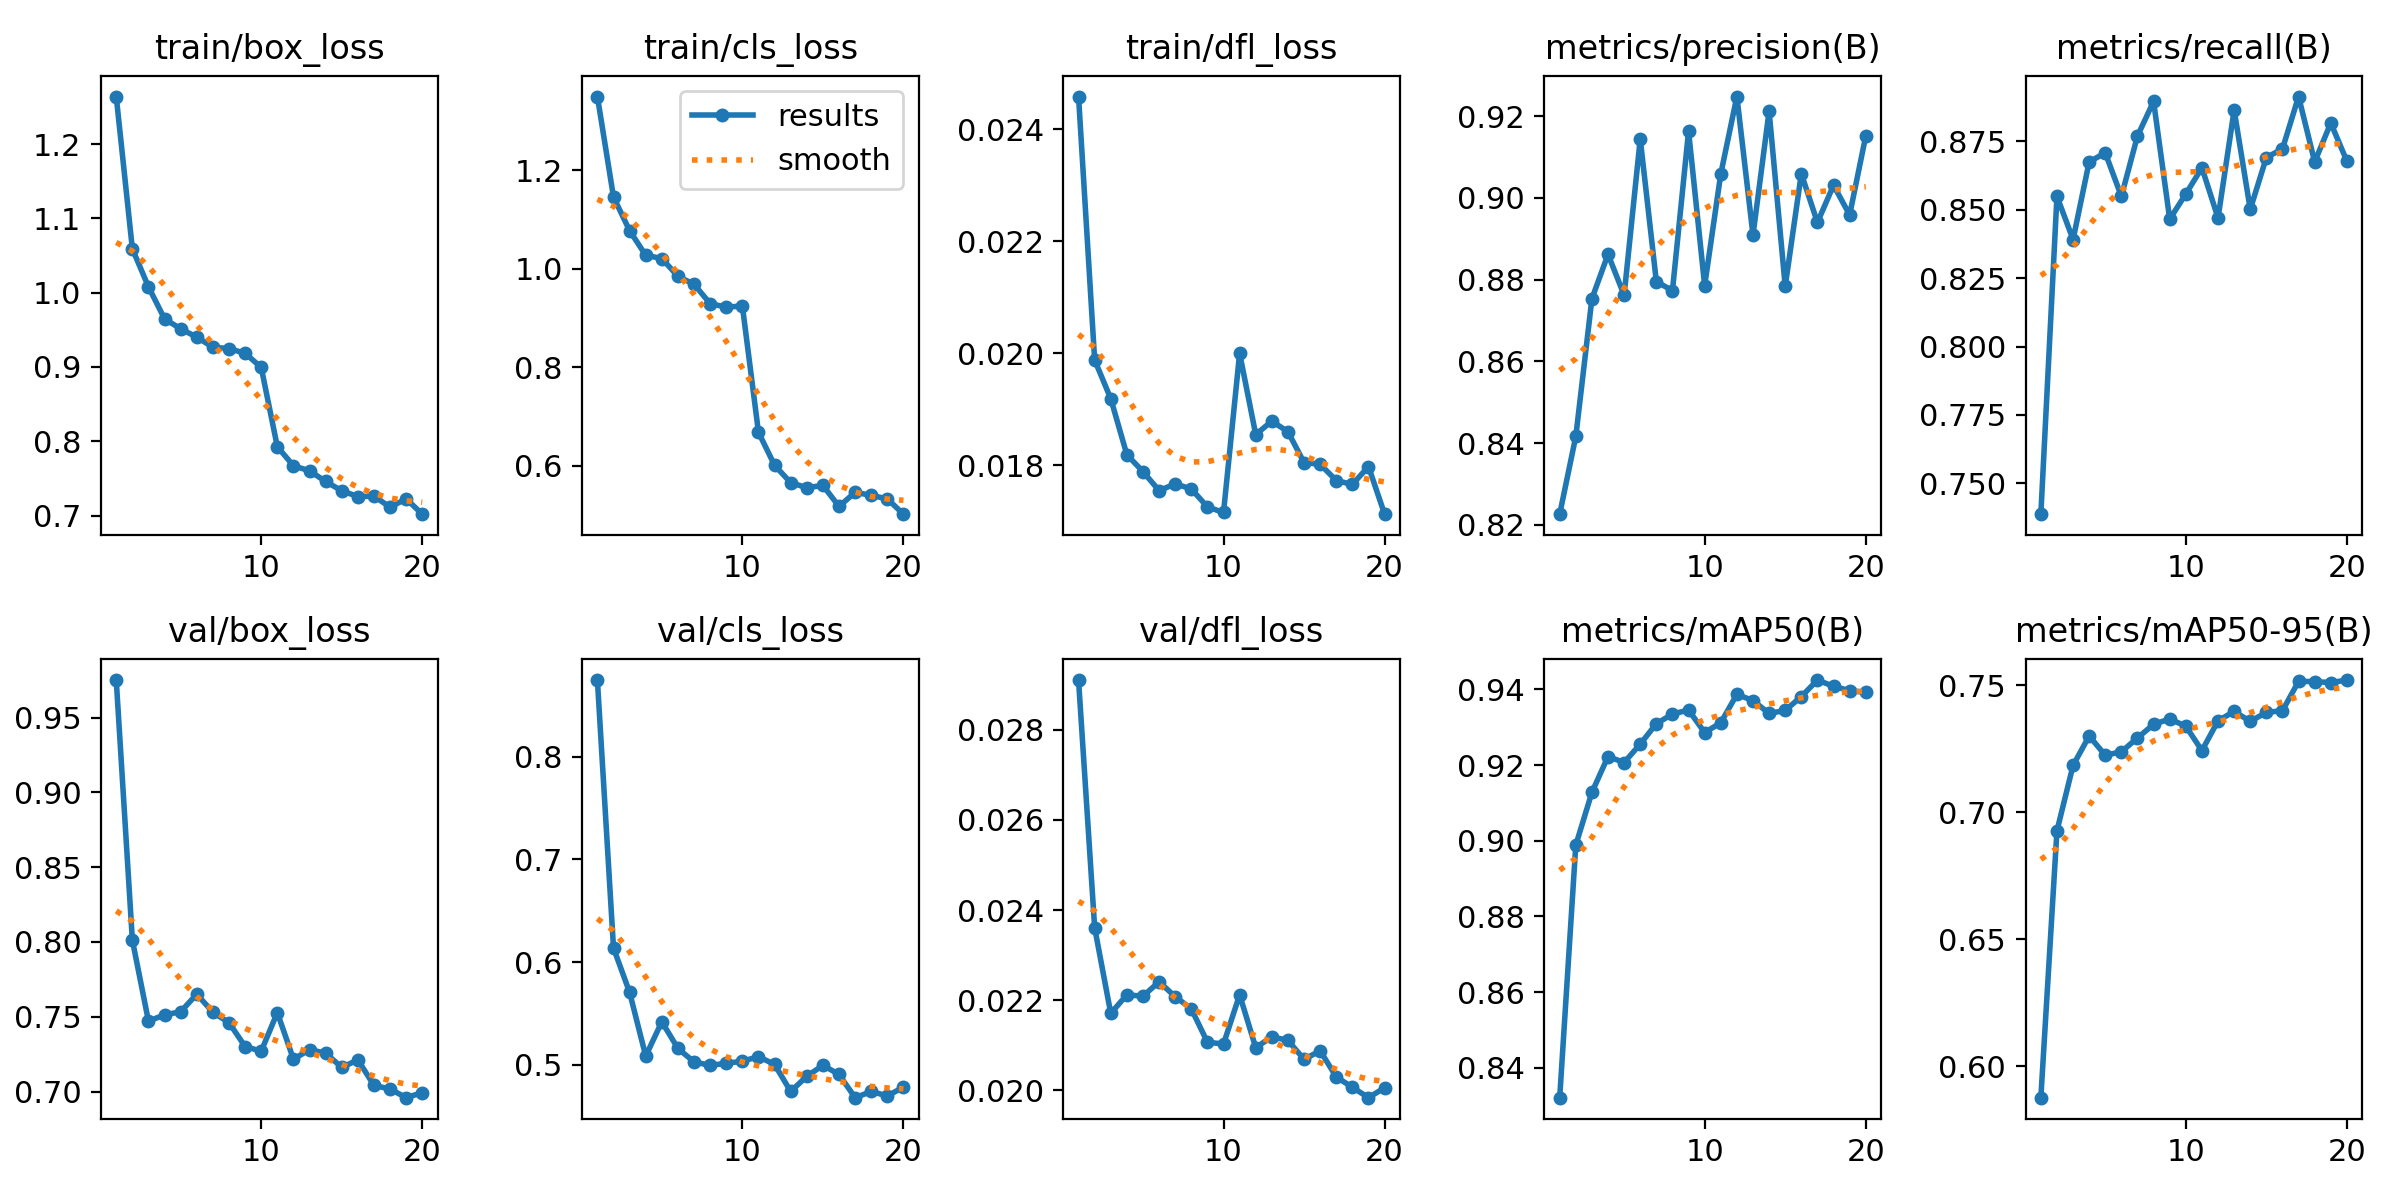


v4_yolo26s_aug_coslr
Showing: runs\detect\runs\cats_v4_yolo26s_aug_coslr\results.png


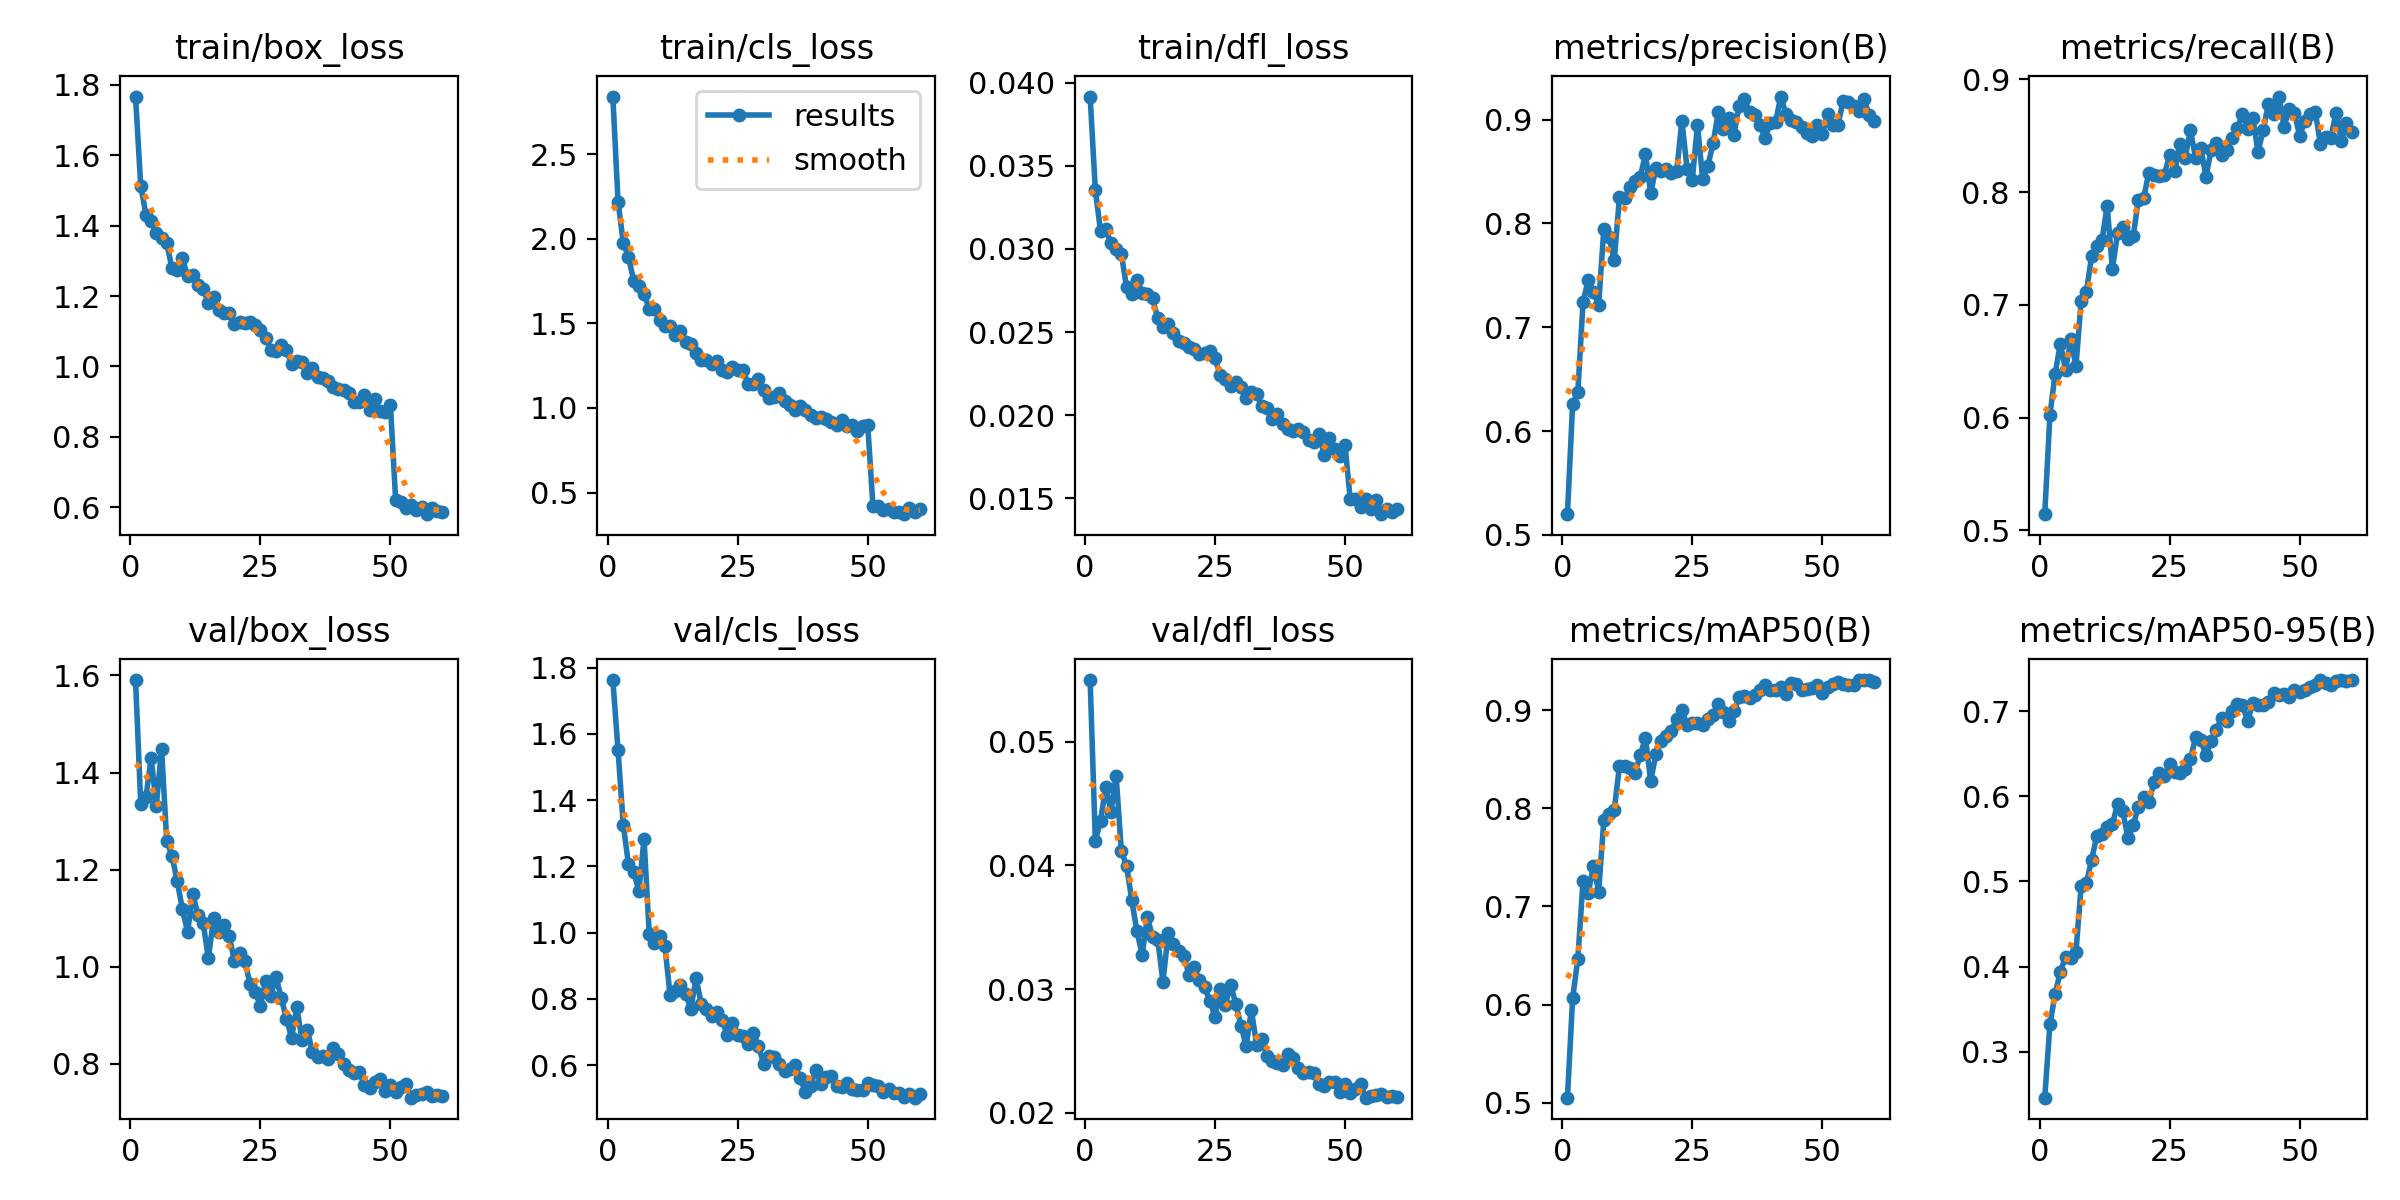


v5_yolo26n_60epochs_low_lr
Showing: runs\detect\runs\cats_v5_yolo26n_60epochs_low_lr\results.png


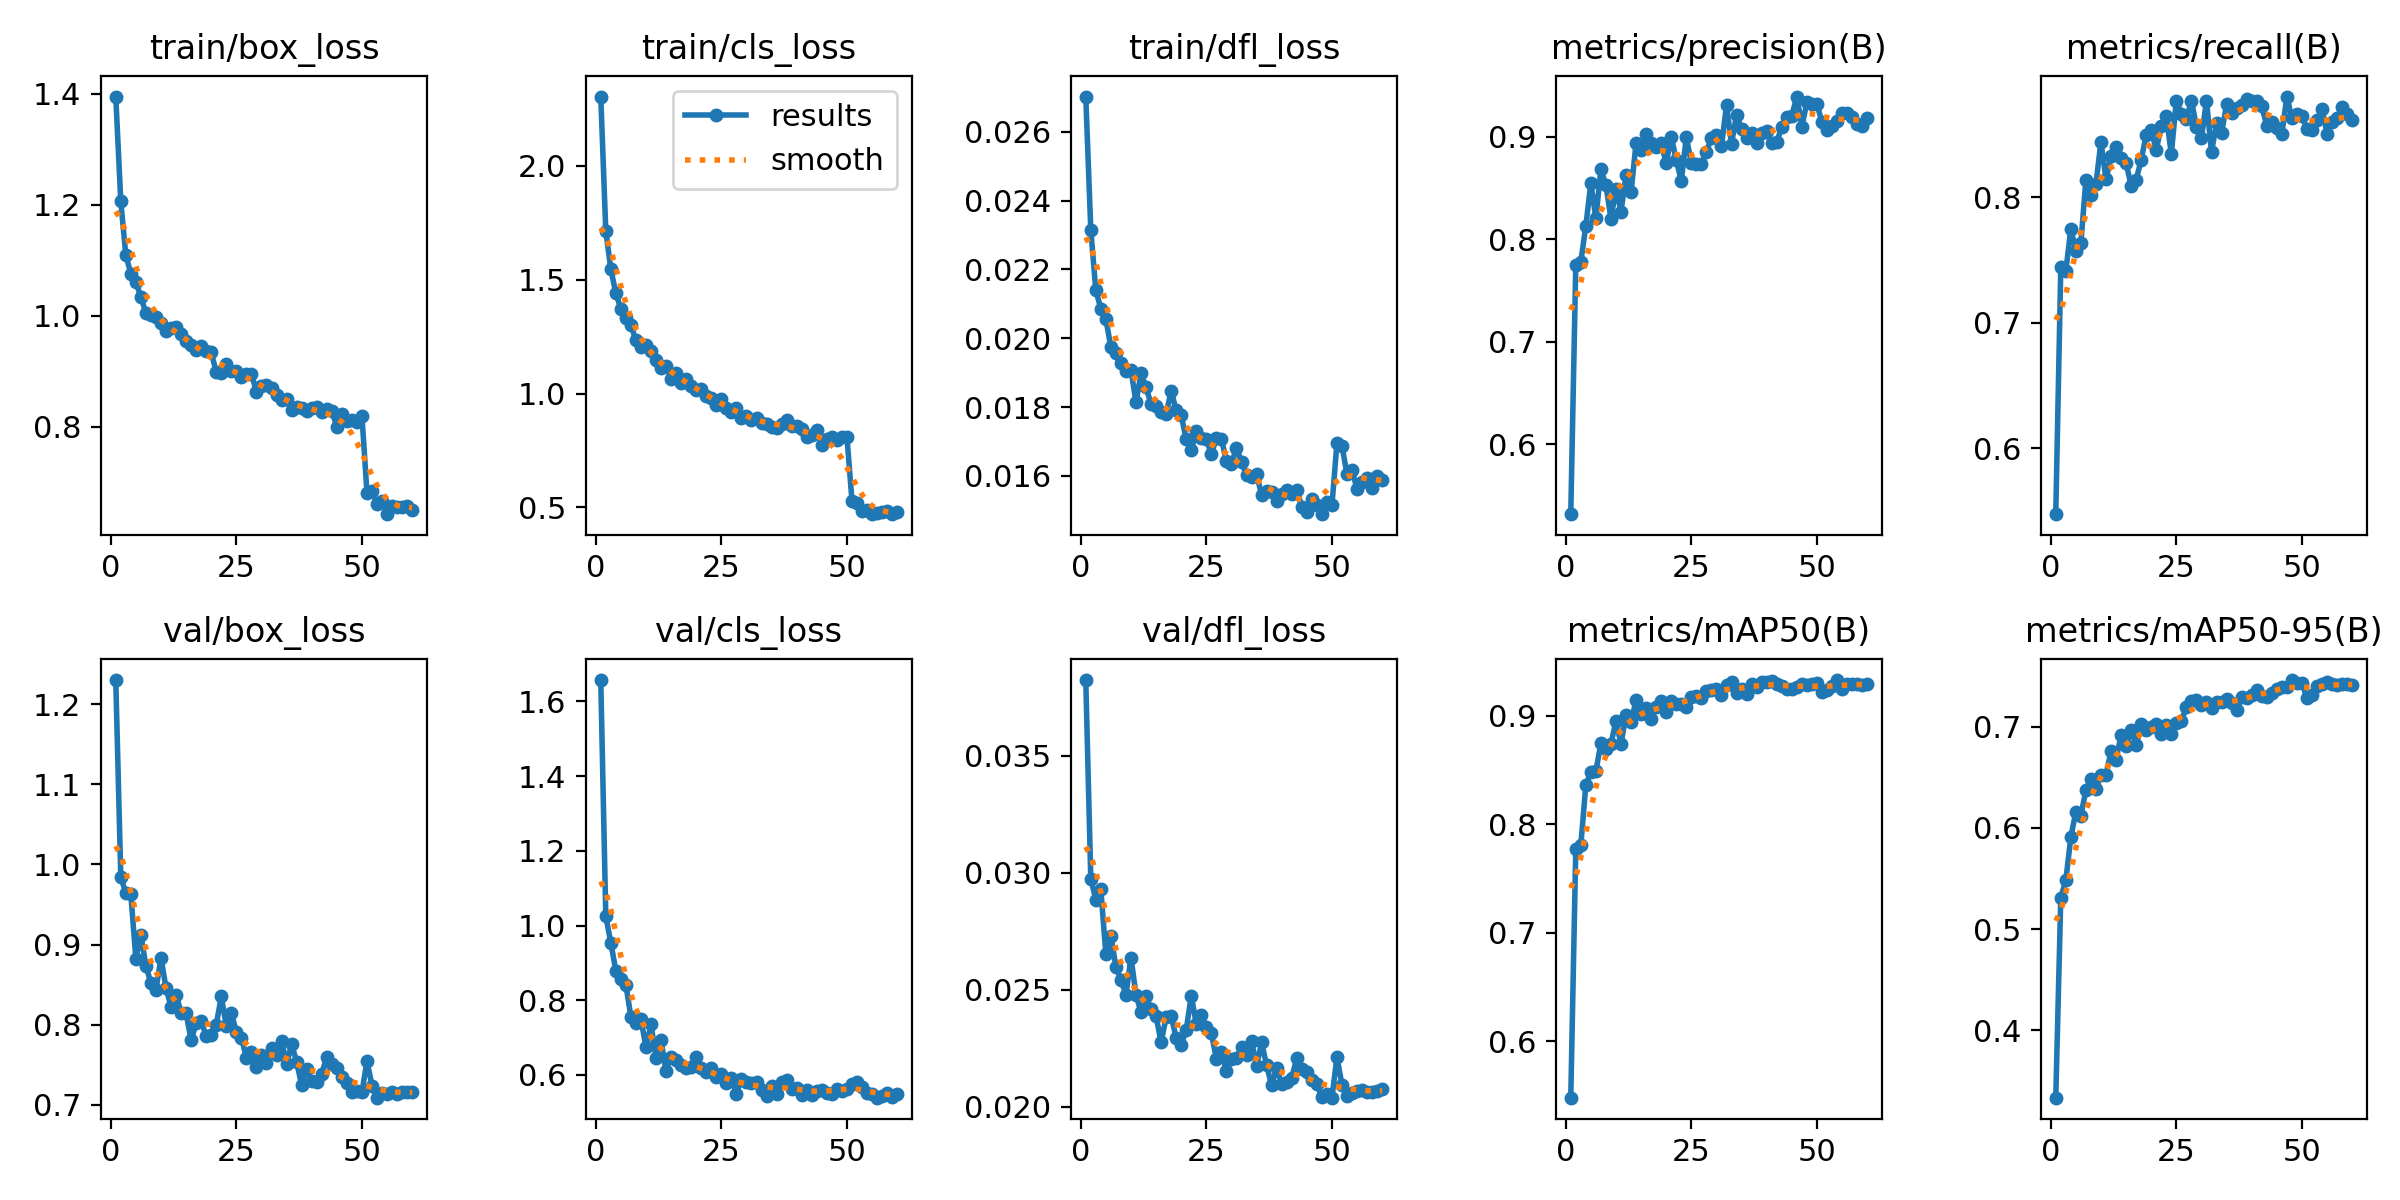


v6_v3_recipe_60epochs
Showing: runs\detect\runs\cats_v6_v3_recipe_60epochs\results.png


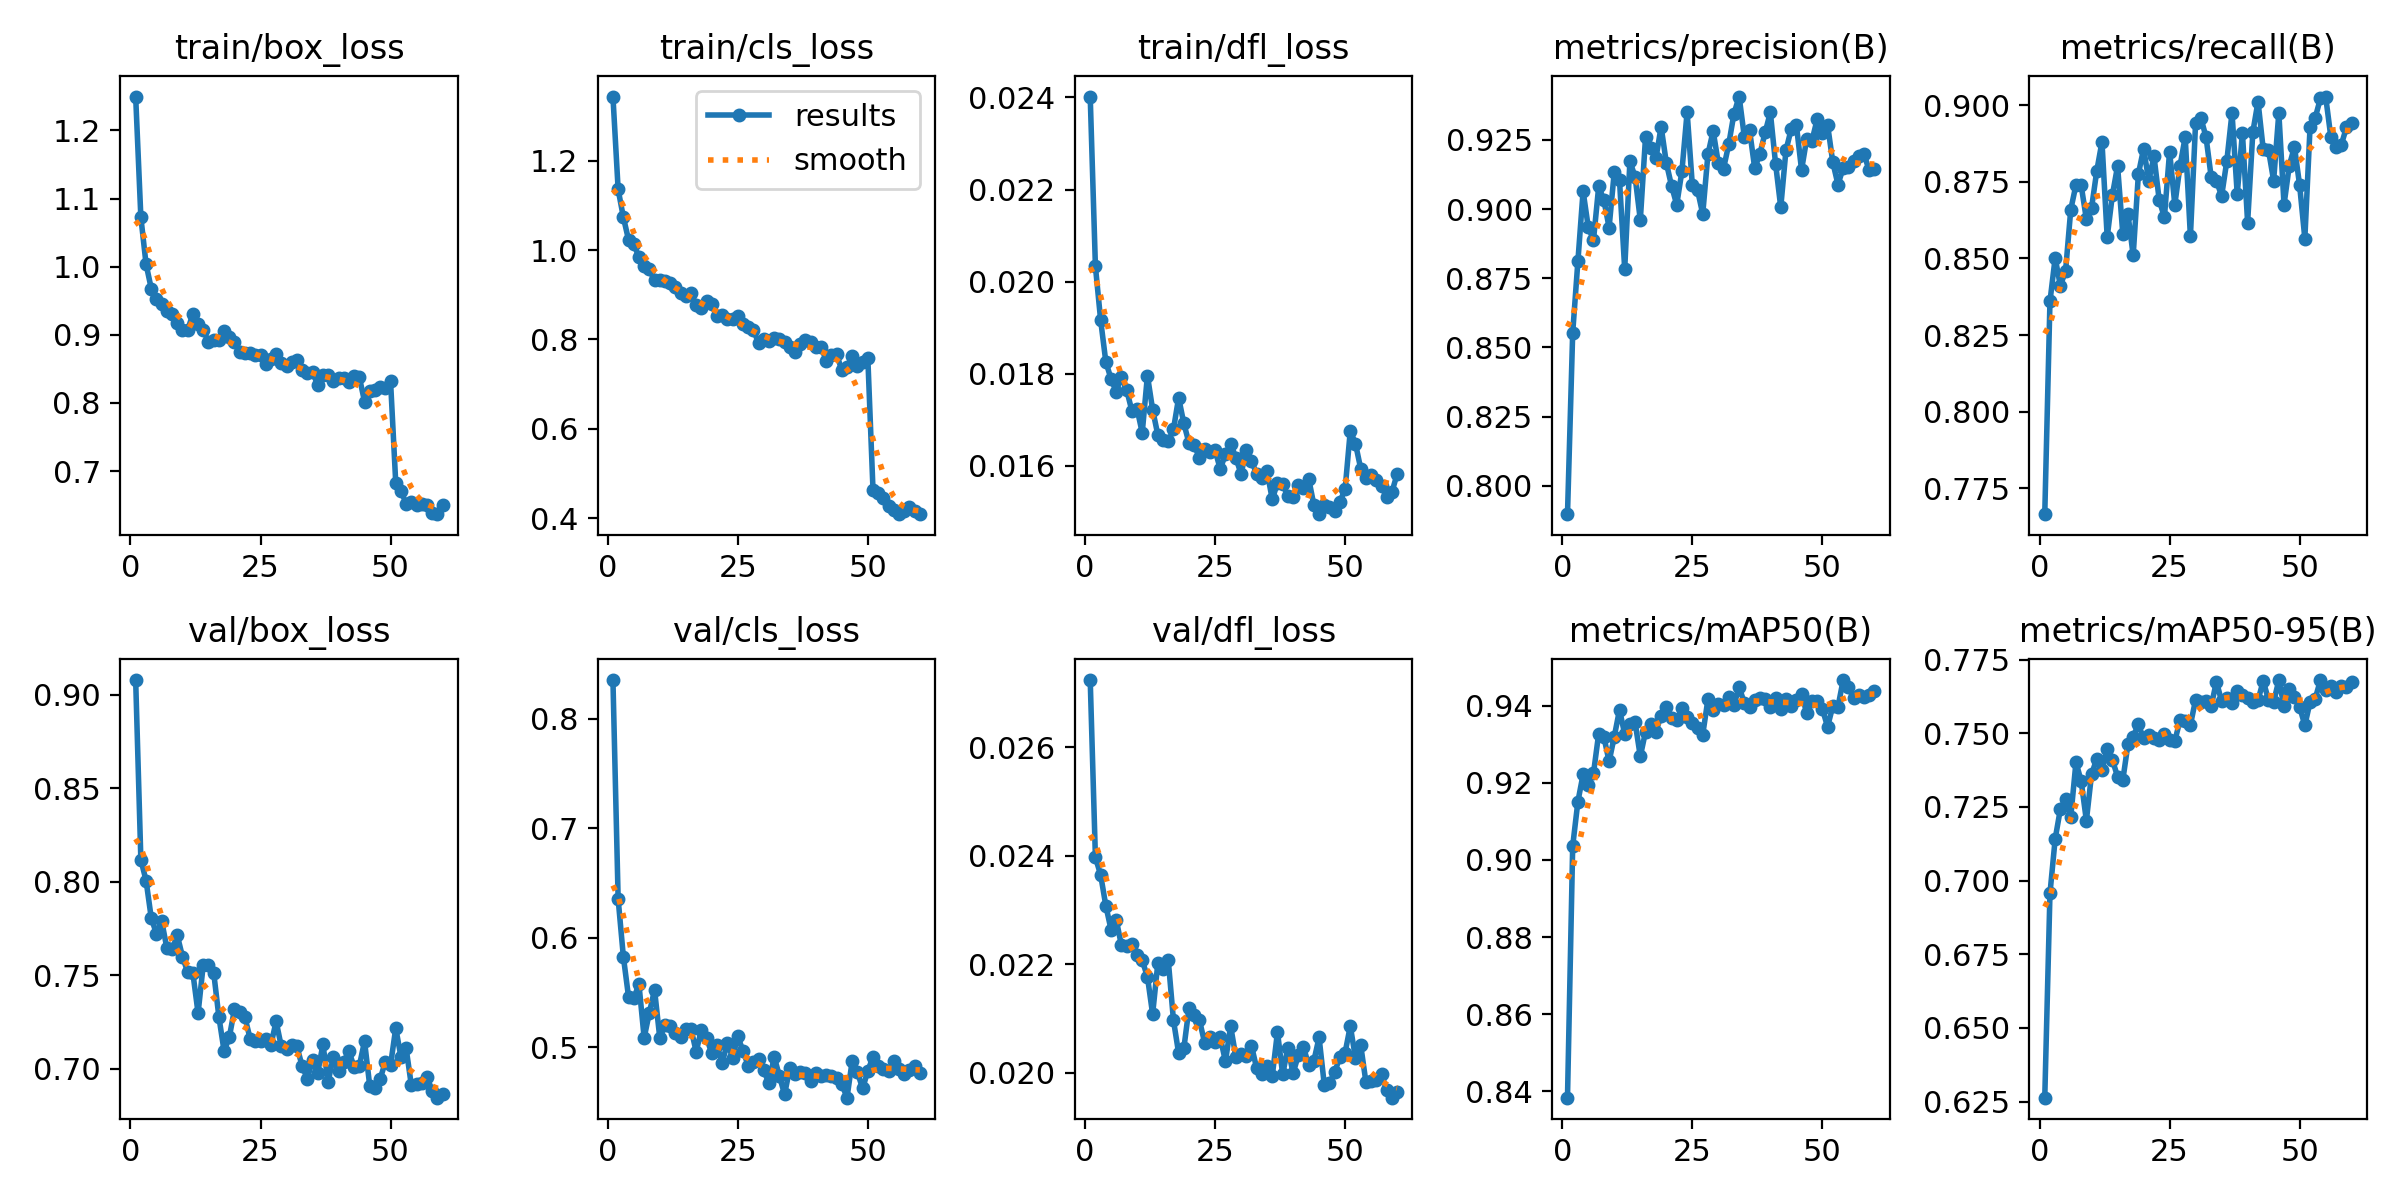

In [41]:
from pathlib import Path
from IPython.display import Image, display

curve_candidates = {
    "v3_hardneg_low_lr": [
        Path("runs/cats_v3_hardneg_low_lr/results.png"),
        Path("runs/detect/runs/cats_v3_hardneg_low_lr/results.png"),
    ],
    "v4_yolo26s_aug_coslr": [
        Path("runs/cats_v4_yolo26s_aug_coslr/results.png"),
        Path("runs/detect/runs/cats_v4_yolo26s_aug_coslr/results.png"),
    ],
    "v5_yolo26n_60epochs_low_lr": [
        Path("runs/cats_v5_yolo26n_60epochs_low_lr/results.png"),
        Path("runs/detect/runs/cats_v5_yolo26n_60epochs_low_lr/results.png"),
    ],
    "v6_v3_recipe_60epochs": [
        Path("runs/cats_v6_v3_recipe_60epochs/results.png"),
        Path("runs/detect/runs/cats_v6_v3_recipe_60epochs/results.png"),
    ],
}

for run_name, paths in curve_candidates.items():
    print("\n" + "=" * 80)
    print(run_name)
    print("=" * 80)

    curve_path = next((p for p in paths if p.exists()), None)

    if curve_path is None:
        print("results.png not found")
    else:
        print("Showing:", curve_path)
        display(Image(filename=str(curve_path)))

## Final Candidate Comparison and Model Choice

Before exporting the final model to ONNX, I compared all available candidate checkpoints on the same held-out test split.

The purpose of this comparison was to avoid choosing a model only because it was larger or trained for more epochs. In object detection, a larger backbone does not always guarantee better final performance. A larger model can have more capacity, but it can also be harder to tune, more sensitive to augmentation settings, slower during inference, and less practical for deployment.

The main candidate models were:

| Run | Backbone | Main idea |
|---|---|---|
| Week-1 baseline | YOLO26n | Original cleaned cat dataset |
| v2_hardneg | YOLO26n | First hard-negative fine-tuning attempt |
| v3_hardneg_low_lr | YOLO26n | Hard negatives + AdamW + low learning rate + early stopping |
| v4_yolo26s_aug_coslr | YOLO26s | Larger backbone + stronger augmentation + cosine LR |
| v5_yolo26n_60epochs_low_lr | YOLO26n | Fresh YOLO26n training for 60 epochs with low LR and cosine LR |
| v6_v3_recipe_60epochs | YOLO26n | Extended version of the successful v3-style recipe |

The v4 experiment tested whether a larger `YOLO26s` model could outperform the smaller `YOLO26n` checkpoints. This was a useful experiment because larger models can sometimes improve localization and robustness. However, in this project the larger model did not automatically become the best choice. The stronger augmentation and larger backbone improved some aspects of training, but the model was heavier and did not clearly outperform the best YOLO26n candidates.

This result is reasonable. The dataset is relatively focused on a single class, `cat`, and the main weakness was not lack of model size. The main weakness was false positives on non-cat images. Because of that, better data discipline, hard negatives, careful fine-tuning, and lower learning rate were more important than simply increasing the model size.

The v3 and v6-style models are especially strong because they start from a Week-1 cat detector that already learned the target class well. Then they fine-tune on the hard-negative dataset with a lower learning rate. This helps the model keep its cat-detection ability while learning to avoid predicting cats on dogs, toys, rooms, humans, and other non-cat images.

For final deployment, I also consider model practicality. If a smaller YOLO26n model performs similarly to or better than a larger YOLO26s model, the smaller model is preferred because it is lighter, faster, easier to export, and more suitable for the Docker inference container.

Therefore, the final model is selected using the held-out test comparison and false-positive analysis, not only validation logs. The selected checkpoint will be exported to ONNX and used as the frozen deployment model.

## Final Checkpoint Path

Before exporting the model to ONNX, I first verify which PyTorch checkpoint will be exported.

If the final model path was already selected in the previous comparison step, I use that path. Otherwise, I manually set the final checkpoint to the best current candidate model.

This check prevents exporting the wrong model and confirms that the selected `best.pt` file exists before moving to ONNX export.

In [42]:
from pathlib import Path

if "FINAL_MODEL_PATH" not in globals():
    FINAL_RUN_NAME = "v6_v3_recipe_60epochs"
    FINAL_MODEL_PATH = "runs/detect/runs/cats_v6_v3_recipe_60epochs/weights/best.pt"

FINAL_MODEL_PATH = Path(FINAL_MODEL_PATH)

print("Final run name:", FINAL_RUN_NAME if "FINAL_RUN_NAME" in globals() else "manual")
print("Final model path:", FINAL_MODEL_PATH)
print("Exists:", FINAL_MODEL_PATH.exists())

if not FINAL_MODEL_PATH.exists():
    raise FileNotFoundError(f"Final model checkpoint not found: {FINAL_MODEL_PATH}")

Final run name: v6_v3_recipe_60epochs
Final model path: runs\detect\runs\cats_v6_v3_recipe_60epochs\weights\best.pt
Exists: True


## Export Final Model to ONNX

After comparing all candidate checkpoints, I export the selected final model to ONNX.


In [43]:
from ultralytics import YOLO
from pathlib import Path
import shutil

final_pt_model = YOLO(str(FINAL_MODEL_PATH))

export_result = final_pt_model.export(
    format="onnx",
    imgsz=640,
    opset=17,
    dynamic=False
)

exported_onnx_path = Path(export_result)

print("Exported ONNX path:", exported_onnx_path)
print("Exists:", exported_onnx_path.exists())

if not exported_onnx_path.exists():
    raise FileNotFoundError("ONNX export failed or exported file was not found.")

Ultralytics 8.4.50  Python-3.13.0 torch-2.12.0+cu126 CPU (AMD Ryzen 5 7535HS with Radeon Graphics)
YOLO26n summary (fused): 122 layers, 2,375,031 parameters, 0 gradients, 5.2 GFLOPs

PyTorch: starting from 'runs\detect\runs\cats_v6_v3_recipe_60epochs\weights\best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 300, 6) (5.1 MB)
requirements: Ultralytics requirements ['onnxslim>=0.1.71', 'onnxruntime-gpu'] not found, attempting AutoUpdate...
Using Python 3.13.0 environment at: C:\Users\user\AppData\Local\Programs\Python\Python313
Resolved 12 packages in 1.10s
Prepared 2 packages in 20.95s
Installed 2 packages in 466ms
 + onnxruntime-gpu==1.26.0
 + onnxslim==0.1.94

requirements: AutoUpdate success  24.1s
WARNING requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.21.0 opset 17...


C:\Users\user\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\onnx\_internal\torchscript_exporter\symbolic_opset11.py:954: UserWarning: Exporting aten::index operator of advanced indexing in opset 17 is achieved by combination of multiple ONNX operators, including Reshape, Transpose, Concat, and Gather. If indices include negative values, the exported graph will produce incorrect results.
  return opset9.index(g, self, index)


ONNX: slimming with onnxslim 0.1.94...
ONNX: export success  28.4s, saved as 'runs\detect\runs\cats_v6_v3_recipe_60epochs\weights\best.onnx' (9.4 MB)

Export complete (28.8s)
Results saved to C:\Users\user\Documents\IronHack_Labs\m6-09-assessment\runs\detect\runs\cats_v6_v3_recipe_60epochs\weights\best.onnx
Predict:         yolo predict task=detect model=runs\detect\runs\cats_v6_v3_recipe_60epochs\weights\best.onnx imgsz=640 
Validate:        yolo val task=detect model=runs\detect\runs\cats_v6_v3_recipe_60epochs\weights\best.onnx imgsz=640 data=data_v2.yaml  
Visualize:       https://netron.app
Exported ONNX path: runs\detect\runs\cats_v6_v3_recipe_60epochs\weights\best.onnx
Exists: True


In [44]:
from pathlib import Path
import shutil

container_model_dir = Path("container/models")
container_model_dir.mkdir(parents=True, exist_ok=True)

container_onnx_path = container_model_dir / "best.onnx"

shutil.copy2(exported_onnx_path, container_onnx_path)

print("Copied ONNX to:", container_onnx_path)
print("Exists:", container_onnx_path.exists())

if not container_onnx_path.exists():
    raise FileNotFoundError("ONNX file was not copied to container/models/best.onnx")

Copied ONNX to: container\models\best.onnx
Exists: True


## ONNX Runtime Sanity Check

After exporting the model, I load `container/models/best.onnx` with ONNX Runtime.

This check confirms that the exported model can be used outside the original PyTorch training environment.

First, I inspect the ONNX model input and output shapes. Then I run inference on a small set of held-out test images.

In [45]:
import onnxruntime as ort
from pathlib import Path

onnx_path = Path("container/models/best.onnx")

print("ONNX path:", onnx_path)
print("Exists:", onnx_path.exists())

if not onnx_path.exists():
    raise FileNotFoundError("container/models/best.onnx not found. Run the ONNX export cell first.")

session = ort.InferenceSession(
    str(onnx_path),
    providers=["CPUExecutionProvider"]
)

print("ONNX Runtime providers:", session.get_providers())

ONNX path: container\models\best.onnx
Exists: True
ONNX Runtime providers: ['CPUExecutionProvider']


In [46]:
print("Inputs:")
for inp in session.get_inputs():
    print("Name:", inp.name)
    print("Shape:", inp.shape)
    print("Type:", inp.type)
    print()

print("Outputs:")
for out in session.get_outputs():
    print("Name:", out.name)
    print("Shape:", out.shape)
    print("Type:", out.type)
    print()

Inputs:
Name: images
Shape: [1, 3, 640, 640]
Type: tensor(float)

Outputs:
Name: output0
Shape: [1, 300, 6]
Type: tensor(float)



## ONNX Runtime Sanity Check Result

The exported ONNX model was successfully loaded with ONNX Runtime from `container/models/best.onnx`.

The model input shape is `[1, 3, 640, 640]`, which means the model expects one RGB image resized to 640x640 with channel-first format.

The model output shape is `[1, 300, 6]`. This confirms that the exported model uses the expected YOLO26 end-to-end detection format. Each output row represents one possible detection in this structure:

`[xmin, ymin, xmax, ymax, confidence, class_id]`

This is important because the final Docker container will use the ONNX model directly with ONNX Runtime. If the model could not be loaded here, or if the output format was different from expected, the deployment code would be risky.

The sanity check confirms that the exported ONNX file is valid, can be loaded outside the PyTorch training environment, and has the correct input/output format for the next deployment step.

In [47]:
from pathlib import Path

DATA_ROOT = Path("data/DATA_CLEAN_LAST")
TEST_LIST = DATA_ROOT / "test.txt"

if not TEST_LIST.exists():
    raise FileNotFoundError(f"Missing test split file: {TEST_LIST}")

with open(TEST_LIST, "r", encoding="utf-8") as f:
    all_test_images = [line.strip() for line in f if line.strip()]

sample_images = []

for image_path in all_test_images:
    p = Path(image_path)

    if not p.exists():
        p = DATA_ROOT / "images" / p.name

    if p.exists():
        sample_images.append(p)

sample_images = sample_images[:8]

print("Number of sample images:", len(sample_images))
for p in sample_images:
    print(p)

Number of sample images: 8
C:\Users\user\Documents\IronHack_Labs\m6-09-assessment\data\DATA_CLEAN_LAST\images\0da5ec5d4df2f79a.jpg
C:\Users\user\Documents\IronHack_Labs\m6-09-assessment\data\DATA_CLEAN_LAST\images\neg_dog_0324.jpg
C:\Users\user\Documents\IronHack_Labs\m6-09-assessment\data\DATA_CLEAN_LAST\images\49e364bf4cee5887.jpg
C:\Users\user\Documents\IronHack_Labs\m6-09-assessment\data\DATA_CLEAN_LAST\images\neg_dog_0000.jpg
C:\Users\user\Documents\IronHack_Labs\m6-09-assessment\data\DATA_CLEAN_LAST\images\138727ef02349ead.jpg
C:\Users\user\Documents\IronHack_Labs\m6-09-assessment\data\DATA_CLEAN_LAST\images\9bb221d4820b7d67.jpg
C:\Users\user\Documents\IronHack_Labs\m6-09-assessment\data\DATA_CLEAN_LAST\images\3dd3ac6396aaf4cc.jpg
C:\Users\user\Documents\IronHack_Labs\m6-09-assessment\data\DATA_CLEAN_LAST\images\c3299b523e7441f4.jpg


In [48]:
import numpy as np
from PIL import Image

def letterbox_pil(image, imgsz=640):
    """
    Resize image with unchanged aspect ratio and add padding.
    This matches the typical YOLO preprocessing style.
    """
    orig_w, orig_h = image.size

    scale = min(imgsz / orig_w, imgsz / orig_h)

    new_w = int(round(orig_w * scale))
    new_h = int(round(orig_h * scale))

    resized = image.resize((new_w, new_h), Image.BILINEAR)

    padded = Image.new("RGB", (imgsz, imgsz), (114, 114, 114))

    pad_x = (imgsz - new_w) // 2
    pad_y = (imgsz - new_h) // 2

    padded.paste(resized, (pad_x, pad_y))

    return padded, scale, pad_x, pad_y


def run_onnxruntime_prediction(image_path, session, imgsz=640, conf_threshold=0.25):
    """
    Run ONNX Runtime inference and map boxes back to original image coordinates.
    Expected ONNX output shape: (1, 300, 6)
    Each detection: [x1, y1, x2, y2, confidence, class_id]
    """
    image = Image.open(image_path).convert("RGB")
    orig_w, orig_h = image.size

    padded, scale, pad_x, pad_y = letterbox_pil(image, imgsz=imgsz)

    x = np.asarray(padded, dtype=np.float32) / 255.0
    x = np.transpose(x, (2, 0, 1))
    x = np.expand_dims(x, axis=0)

    input_name = session.get_inputs()[0].name
    outputs = session.run(None, {input_name: x})

    detections = outputs[0]

    if detections.ndim == 3:
        detections = detections[0]

    results = []

    for det in detections:
        x1, y1, x2, y2, score, cls_id = det[:6]

        score = float(score)

        if score < conf_threshold:
            continue

        x1 = (float(x1) - pad_x) / scale
        y1 = (float(y1) - pad_y) / scale
        x2 = (float(x2) - pad_x) / scale
        y2 = (float(y2) - pad_y) / scale

        x1 = max(0.0, min(orig_w, x1))
        y1 = max(0.0, min(orig_h, y1))
        x2 = max(0.0, min(orig_w, x2))
        y2 = max(0.0, min(orig_h, y2))

        results.append({
            "xmin": x1,
            "ymin": y1,
            "xmax": x2,
            "ymax": y2,
            "confidence": score,
            "class": "cat",
        })

    return results

In [49]:
import pandas as pd

onnx_runtime_rows = []

for image_path in sample_images:
    detections = run_onnxruntime_prediction(
        image_path=image_path,
        session=session,
        imgsz=640,
        conf_threshold=0.25
    )

    onnx_runtime_rows.append({
        "image": image_path.name,
        "num_detections": len(detections),
        "top_confidence": max([d["confidence"] for d in detections], default=0.0),
    })

onnx_runtime_df = pd.DataFrame(onnx_runtime_rows)
display(onnx_runtime_df)

,image,num_detections,top_confidence
0,0da5ec5d4df2f79a.jpg,1,0.907884
1,neg_dog_0324.jpg,0,0.000000
2,49e364bf4cee5887.jpg,1,0.783948
3,neg_dog_0000.jpg,0,0.000000
4,138727ef02349ead.jpg,2,0.935466
5,9bb221d4820b7d67.jpg,1,0.821940
6,3dd3ac6396aaf4cc.jpg,1,0.875788
7,c3299b523e7441f4.jpg,1,0.853984


## PyTorch vs ONNX Prediction Check

After confirming that the ONNX model loads and runs with ONNX Runtime, I compare it against the original PyTorch checkpoint.

The goal of this check is to confirm that the exported ONNX model behaves consistently enough for deployment. I compare the predictions on the same sample test images using:

- number of detections per image
- bounding-box coordinates
- confidence scores

The outputs do not need to be bit-for-bit identical because PyTorch and ONNX Runtime can use different inference backends, preprocessing details, and low-level numerical operations.

For this sanity check, the most important signal is whether the ONNX model detects the same objects and produces usable bounding-box predictions. If detection counts match and predictions remain reasonable, the export can be considered valid for the container stage.

In [51]:
from ultralytics import YOLO
import numpy as np
import pandas as pd

pt_model = YOLO(str(FINAL_MODEL_PATH))
onnx_ultralytics_model = YOLO(str(container_onnx_path), task="detect")
comparison_rows = []

for image_path in sample_images:
    pt_result = pt_model.predict(
        source=str(image_path),
        imgsz=640,
        conf=0.25,
        device=0,
        verbose=False
    )[0]

    onnx_result = onnx_ultralytics_model.predict(
        source=str(image_path),
        imgsz=640,
        conf=0.25,
        verbose=False
    )[0]

    pt_boxes = pt_result.boxes
    onnx_boxes = onnx_result.boxes

    pt_count = 0 if pt_boxes is None else len(pt_boxes)
    onnx_count = 0 if onnx_boxes is None else len(onnx_boxes)

    max_box_diff = None
    max_conf_diff = None

    if pt_count > 0 and onnx_count > 0:
        common_count = min(pt_count, onnx_count)

        pt_xyxy = pt_boxes.xyxy[:common_count].cpu().numpy()
        onnx_xyxy = onnx_boxes.xyxy[:common_count].cpu().numpy()

        pt_conf = pt_boxes.conf[:common_count].cpu().numpy()
        onnx_conf = onnx_boxes.conf[:common_count].cpu().numpy()

        max_box_diff = float(np.max(np.abs(pt_xyxy - onnx_xyxy)))
        max_conf_diff = float(np.max(np.abs(pt_conf - onnx_conf)))

    comparison_rows.append({
        "image": image_path.name,
        "pt_detections": pt_count,
        "onnx_detections": onnx_count,
        "same_detection_count": pt_count == onnx_count,
        "max_box_diff": max_box_diff,
        "max_conf_diff": max_conf_diff,
    })

pt_onnx_comparison_df = pd.DataFrame(comparison_rows)
display(pt_onnx_comparison_df)

Loading container\models\best.onnx for ONNX Runtime inference...
Using ONNX Runtime 1.26.0 with CUDAExecutionProvider


,image,pt_detections,onnx_detections,same_detection_count,max_box_diff,max_conf_diff
0,0da5ec5d4df2f79a.jpg,1,1,True,7.555176,0.003887
1,neg_dog_0324.jpg,0,0,True,NaN,NaN
2,49e364bf4cee5887.jpg,2,2,True,9.260559,0.047090
3,neg_dog_0000.jpg,0,0,True,NaN,NaN
4,138727ef02349ead.jpg,2,2,True,41.222626,0.223421
5,9bb221d4820b7d67.jpg,1,1,True,3.891296,0.030245
6,3dd3ac6396aaf4cc.jpg,1,1,True,15.263428,0.016579
7,c3299b523e7441f4.jpg,1,1,True,6.030762,0.009883


## PyTorch vs ONNX Comparison Result

The PyTorch checkpoint and the exported ONNX model produced the same number of detections on all sampled test images.

This is the most important result of the sanity check because it shows that the ONNX model is detecting the same number of objects as the original PyTorch model on these examples.

There are some numerical differences in bounding-box coordinates and confidence values. Most of the differences are small or moderate, while one sample has a larger coordinate difference. Because of this, I do not describe the outputs as perfectly identical.

However, the ONNX model loads correctly, produces valid detections, ignores the sampled hard-negative dog images, and remains functionally consistent with the PyTorch checkpoint. Therefore, the exported model is valid for the deployment/container stage.

## ONNX Export Summary

The selected final model was successfully exported from PyTorch to ONNX and copied to `container/models/best.onnx`.

The ONNX model was loaded successfully with ONNX Runtime. Its input and output shapes match the expected YOLO26 end-to-end detection format:

- input: `[1, 3, 640, 640]`
- output: `[1, 300, 6]`

This means the model accepts one 640x640 RGB image and returns up to 300 detections. Each detection contains bounding-box coordinates, confidence score, and class id.

I tested the ONNX model on a small set of held-out test images. The model produced detections on cat images and returned no detections on the sampled hard-negative dog images. This is a good sign because reducing false positives on non-cat images was one of the main goals of the improved model.

I also compared the exported ONNX model with the original PyTorch checkpoint. The detection counts matched for all sampled images, which shows that the ONNX model is detecting the same number of objects as the PyTorch model on these examples.

Some numerical differences in box coordinates and confidence scores were observed. Therefore, I do not claim that the PyTorch and ONNX outputs are perfectly identical. However, the predictions are functionally consistent, the ONNX model loads correctly, and the output format is suitable for the next deployment step.

The ONNX export and sanity-check stage is complete. The next step is to build the Docker inference container around this `best.onnx` model.

# Part B — Containerized Inference

In this section, I prepare the final inference container for the exported ONNX model.

The goal is to build a Docker image that can be used by the instructor on unseen images. The container must follow a fixed interface so that the leaderboard runner can automatically call it.

The container will support two commands:

- `info`
- `predict`

The `info` command prints my student metadata, while the `predict` command runs the ONNX model on input images and writes a prediction CSV file.

For deployment, I use ONNX Runtime directly instead of the full Ultralytics package. This keeps the runtime image smaller and makes inference independent from the training environment.

In [52]:
from pathlib import Path

container_dir = Path("container")
app_dir = container_dir / "app"
models_dir = container_dir / "models"

container_dir.mkdir(exist_ok=True)
app_dir.mkdir(parents=True, exist_ok=True)
models_dir.mkdir(parents=True, exist_ok=True)

init_file = app_dir / "__init__.py"
init_file.write_text("", encoding="utf-8")

paths_to_check = [
    container_dir,
    app_dir,
    models_dir,
    init_file,
    models_dir / "best.onnx",
]

for path in paths_to_check:
    print(f"{path} -> {path.exists()}")

container -> True
container\app -> True
container\models -> True
container\app\__init__.py -> True
container\models\best.onnx -> True


## Container Repository Layout

The required container structure is now created inside the repository.

The most important file is `container/models/best.onnx`, because this is the exported model that will be used during inference.

The `app` folder will contain the Python inference code. The container will load the ONNX model once, run predictions on all input images, and write results in the required CSV format.

## Student Metadata

The leaderboard runner identifies each submission using `STUDENT.json`.

This file contains my name, team slug, model framework, model variant, image size, training details, and a short note about the final model.

The file must be placed at `container/STUDENT.json`. During Docker build, it will also be copied into the image at `/app/STUDENT.json`.

In [53]:
import json
from pathlib import Path

student_info = {
    "first_name": "Kamal",
    "last_name": "Musayev",
    "team": "kamal-musayev",
    "model": {
        "framework": "yolo26",
        "variant": "yolo26n",
        "imgsz": 640,
        "epochs_total": 60,
        "tricks": [
            "hard_negatives",
            "transfer_learning_from_week1",
            "low_lr_finetuning",
            "adamw",
            "early_stopping"
        ]
    },
    "notes": "Final YOLO26n model selected after test-set comparison and exported to ONNX for containerized inference."
}

student_path = Path("container/STUDENT.json")

student_path.write_text(
    json.dumps(student_info, indent=2),
    encoding="utf-8"
)

print("Created:", student_path)
print(student_path.read_text(encoding="utf-8"))

Created: container\STUDENT.json
{
  "first_name": "Kamal",
  "last_name": "Musayev",
  "team": "kamal-musayev",
  "model": {
    "framework": "yolo26",
    "variant": "yolo26n",
    "imgsz": 640,
    "epochs_total": 60,
    "tricks": [
      "hard_negatives",
      "transfer_learning_from_week1",
      "low_lr_finetuning",
      "adamw",
      "early_stopping"
    ]
  },
  "notes": "Final YOLO26n model selected after test-set comparison and exported to ONNX for containerized inference."
}


## Runtime Requirements

The Docker image should stay lightweight.

For inference, I do not need the full Ultralytics training package. The runtime only needs ONNX Runtime for model execution, NumPy for array processing, Pillow for image loading, and OpenCV headless as a common image-processing dependency.

Keeping the runtime dependencies small improves reproducibility and reduces the final Docker image size.

In [4]:
from pathlib import Path

requirements_text = """onnxruntime==1.18.0
numpy<2
pillow
opencv-python-headless
"""

requirements_path = Path("container/requirements.txt")
requirements_path.write_text(requirements_text, encoding="utf-8")

print("Created:", requirements_path)
print(requirements_path.read_text())

Created: container\requirements.txt
onnxruntime==1.18.0
numpy<2
pillow
opencv-python-headless



## First Container Setup Check

At this point, the basic container structure is ready.

The repository now has the metadata file, runtime requirements file, application folder, and exported ONNX model location prepared.

Next, I will implement the actual inference logic in `detector.py` and the command-line interface in `cli.py`.

## Inference Detector

The `detector.py` file contains the core inference logic for the container.

It loads the exported ONNX model once using ONNX Runtime and exposes a `predict(image_path)` method.

For each input image, the detector:

- opens the image with Pillow
- resizes it to 640x640 using letterbox padding
- runs ONNX Runtime inference
- filters detections by confidence score
- maps bounding boxes back to the original image size
- clips box coordinates to image boundaries
- returns predictions as dictionaries

This file does not depend on Ultralytics. It uses only ONNX Runtime, NumPy, and Pillow, which makes it suitable for a lightweight Docker inference container.

In [55]:
from pathlib import Path

detector_code = r'''import numpy as np
import onnxruntime as ort
from PIL import Image


class CatDetector:
    def __init__(self, onnx_path, imgsz=640, conf=0.25, class_names=("cat",)):
        self.onnx_path = onnx_path
        self.imgsz = imgsz
        self.conf = conf
        self.class_names = class_names

        self.session = ort.InferenceSession(
            self.onnx_path,
            providers=["CPUExecutionProvider"]
        )

        self.input_name = self.session.get_inputs()[0].name
        self.output_shape = self.session.get_outputs()[0].shape

    def _letterbox(self, image):
        orig_w, orig_h = image.size

        scale = min(self.imgsz / orig_w, self.imgsz / orig_h)

        new_w = int(round(orig_w * scale))
        new_h = int(round(orig_h * scale))

        resized = image.resize((new_w, new_h), Image.BILINEAR)

        padded = Image.new("RGB", (self.imgsz, self.imgsz), (114, 114, 114))

        pad_x = (self.imgsz - new_w) // 2
        pad_y = (self.imgsz - new_h) // 2

        padded.paste(resized, (pad_x, pad_y))

        return padded, scale, pad_x, pad_y

    def predict(self, image_path):
        image = Image.open(image_path).convert("RGB")
        orig_w, orig_h = image.size

        padded, scale, pad_x, pad_y = self._letterbox(image)

        x = np.asarray(padded, dtype=np.float32) / 255.0
        x = np.transpose(x, (2, 0, 1))
        x = np.expand_dims(x, axis=0)

        outputs = self.session.run(None, {self.input_name: x})
        detections = outputs[0]

        if detections.ndim == 3:
            detections = detections[0]

        results = []

        for det in detections:
            x1, y1, x2, y2, score, cls_id = det[:6]

            score = float(score)

            if score < self.conf:
                continue

            x1 = (float(x1) - pad_x) / scale
            y1 = (float(y1) - pad_y) / scale
            x2 = (float(x2) - pad_x) / scale
            y2 = (float(y2) - pad_y) / scale

            x1 = max(0.0, min(float(orig_w), x1))
            y1 = max(0.0, min(float(orig_h), y1))
            x2 = max(0.0, min(float(orig_w), x2))
            y2 = max(0.0, min(float(orig_h), y2))

            cls_id = int(cls_id)
            class_name = self.class_names[cls_id] if cls_id < len(self.class_names) else str(cls_id)

            results.append({
                "xmin": float(x1),
                "ymin": float(y1),
                "xmax": float(x2),
                "ymax": float(y2),
                "confidence": score,
                "class": class_name,
            })

        return results
'''

detector_path = Path("container/app/detector.py")
detector_path.write_text(detector_code, encoding="utf-8")

print("Created:", detector_path)
print(detector_path.read_text(encoding="utf-8")[:1200])

Created: container\app\detector.py
import numpy as np
import onnxruntime as ort
from PIL import Image


class CatDetector:
    def __init__(self, onnx_path, imgsz=640, conf=0.25, class_names=("cat",)):
        self.onnx_path = onnx_path
        self.imgsz = imgsz
        self.conf = conf
        self.class_names = class_names

        self.session = ort.InferenceSession(
            self.onnx_path,
            providers=["CPUExecutionProvider"]
        )

        self.input_name = self.session.get_inputs()[0].name
        self.output_shape = self.session.get_outputs()[0].shape

    def _letterbox(self, image):
        orig_w, orig_h = image.size

        scale = min(self.imgsz / orig_w, self.imgsz / orig_h)

        new_w = int(round(orig_w * scale))
        new_h = int(round(orig_h * scale))

        resized = image.resize((new_w, new_h), Image.BILINEAR)

        padded = Image.new("RGB", (self.imgsz, self.imgsz), (114, 114, 114))

        pad_x = (self.imgsz - new_w) // 2
        pad

## Detector File Check

The `detector.py` file has been created inside `container/app`.

This file is responsible for model loading and single-image prediction. It keeps the model logic separate from the command-line interface, which makes the container code easier to read and test.

Next, I will create `cli.py`, which provides the required `info` and `predict` commands.

## Command Line Interface

The `cli.py` file provides the required command-line interface for the Docker container.

The container supports two commands:

`info`

This command prints the contents of `STUDENT.json` to standard output. The leaderboard runner uses this command to identify the student submission.

`predict`

This command reads all images from `/data/input/`, runs the ONNX detector, and writes the final prediction file to `/data/output/predictions.csv`.

The output CSV must use the exact required schema:

`image_path,xmin,ymin,xmax,ymax,confidence,class`

If an image has no detections, the CSV still includes one row for that image, with the bounding-box, confidence, and class fields left empty.

In [3]:
from pathlib import Path

cli_code = r'''import argparse
import csv
import json
from pathlib import Path


IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png"}


def run_info():
    student_path = Path("/app/STUDENT.json")

    with student_path.open("r", encoding="utf-8") as f:
        student_info = json.load(f)

    print(json.dumps(student_info, indent=2))


def find_images(input_dir):
    image_paths = []

    for path in input_dir.rglob("*"):
        if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS:
            image_paths.append(path)

    return sorted(image_paths)


def run_predict():
    input_dir = Path("/data/input")
    output_dir = Path("/data/output")
    output_csv = output_dir / "predictions.csv"

    model_path = Path("/app/models/best.onnx")

    if not input_dir.exists():
        raise FileNotFoundError(f"Input directory not found: {input_dir}")

    if not model_path.exists():
        raise FileNotFoundError(f"ONNX model not found: {model_path}")

    output_dir.mkdir(parents=True, exist_ok=True)

    from detector import CatDetector

    detector = CatDetector(
        onnx_path=str(model_path),
        imgsz=640,
        conf=0.25,
        class_names=("cat",)
    )

    image_paths = find_images(input_dir)

    fieldnames = [
        "image_path",
        "xmin",
        "ymin",
        "xmax",
        "ymax",
        "confidence",
        "class",
    ]

    with output_csv.open("w", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()

        for image_path in image_paths:
            relative_path = image_path.relative_to(input_dir).as_posix()

            detections = detector.predict(str(image_path))

            if len(detections) == 0:
                writer.writerow({
                    "image_path": relative_path,
                    "xmin": "",
                    "ymin": "",
                    "xmax": "",
                    "ymax": "",
                    "confidence": "",
                    "class": "",
                })
                continue

            for det in detections:
                writer.writerow({
                    "image_path": relative_path,
                    "xmin": det["xmin"],
                    "ymin": det["ymin"],
                    "xmax": det["xmax"],
                    "ymax": det["ymax"],
                    "confidence": det["confidence"],
                    "class": det["class"],
                })

    print(f"Predictions written to {output_csv}")


def main():
    parser = argparse.ArgumentParser(description="Cat detector container CLI")
    parser.add_argument(
        "command",
        choices=["info", "predict"],
        help="Command to run: info or predict"
    )

    args = parser.parse_args()

    if args.command == "info":
        run_info()
    elif args.command == "predict":
        run_predict()


if __name__ == "__main__":
    main()
'''

cli_path = Path("container/app/cli.py")
cli_path.write_text(cli_code, encoding="utf-8")

print("Created:", cli_path)
print(cli_path.read_text(encoding="utf-8")[:1500])

Created: container\app\cli.py
import argparse
import csv
import json
from pathlib import Path


IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png"}


def run_info():
    student_path = Path("/app/STUDENT.json")

    with student_path.open("r", encoding="utf-8") as f:
        student_info = json.load(f)

    print(json.dumps(student_info, indent=2))


def find_images(input_dir):
    image_paths = []

    for path in input_dir.rglob("*"):
        if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS:
            image_paths.append(path)

    return sorted(image_paths)


def run_predict():
    input_dir = Path("/data/input")
    output_dir = Path("/data/output")
    output_csv = output_dir / "predictions.csv"

    model_path = Path("/app/models/best.onnx")

    if not input_dir.exists():
        raise FileNotFoundError(f"Input directory not found: {input_dir}")

    if not model_path.exists():
        raise FileNotFoundError(f"ONNX model not found: {model_path}")

    output_dir.mkdir(pa

## CLI File Check

The `cli.py` file has been created inside `container/app`.

This file implements the two required commands:

`info` prints the student metadata from `STUDENT.json`.

`predict` loads the ONNX detector, runs inference on all `.jpg`, `.jpeg`, and `.png` files under `/data/input/`, and writes `/data/output/predictions.csv`.

The prediction code preserves relative image paths, including subdirectories, and writes an empty prediction row when an image has no detections. This matches the required leaderboard CSV interface.

## Dockerfile

The Dockerfile defines how the inference container is built.

I use a small Python base image and install only the runtime dependencies from `container/requirements.txt`.

The Docker image copies the application code, ONNX model, and `STUDENT.json` file into `/app`.

The container entrypoint is set to `python /app/app/cli.py`, so the instructor can run the required commands directly:

`info`

or

`predict`

This matches the required standardized container interface.

In [58]:
from pathlib import Path

dockerfile_text = """FROM python:3.11-slim

WORKDIR /app

COPY container/requirements.txt /app/requirements.txt
RUN pip install --no-cache-dir -r /app/requirements.txt

COPY container/app /app/app
COPY container/models /app/models
COPY container/STUDENT.json /app/STUDENT.json

ENTRYPOINT ["python", "/app/app/cli.py"]
"""

dockerfile_path = Path("container/Dockerfile")
dockerfile_path.write_text(dockerfile_text, encoding="utf-8")

print("Created:", dockerfile_path)
print(dockerfile_path.read_text(encoding="utf-8"))

Created: container\Dockerfile
FROM python:3.11-slim

WORKDIR /app

COPY container/requirements.txt /app/requirements.txt
RUN pip install --no-cache-dir -r /app/requirements.txt

COPY container/app /app/app
COPY container/models /app/models
COPY container/STUDENT.json /app/STUDENT.json

ENTRYPOINT ["python", "/app/app/cli.py"]



## Dockerfile Check

The Dockerfile has been created inside the `container` directory.

It installs the lightweight runtime requirements, copies the inference application, copies the exported ONNX model, and copies the student metadata file.

The image entrypoint points to the CLI script, so Docker commands can call the required `info` and `predict` subcommands.

In [59]:
from pathlib import Path

required_container_files = [
    Path("container/Dockerfile"),
    Path("container/STUDENT.json"),
    Path("container/requirements.txt"),
    Path("container/app/__init__.py"),
    Path("container/app/detector.py"),
    Path("container/app/cli.py"),
    Path("container/models/best.onnx"),
]

for path in required_container_files:
    print(f"{path} -> {path.exists()}")

container\Dockerfile -> True
container\STUDENT.json -> True
container\requirements.txt -> True
container\app\__init__.py -> True
container\app\detector.py -> True
container\app\cli.py -> True
container\models\best.onnx -> True


## Container Source Check Result

All required container files were created successfully.

The container directory now includes the Dockerfile, student metadata, runtime requirements, CLI code, detector code, and the exported ONNX model.

This means the container source is ready for Docker build and local testing.

## Container Final Check Result

All required container files were created successfully.

The container directory includes the Dockerfile, student metadata, runtime requirements, CLI code, detector code, and the exported ONNX model.

The Docker image was built successfully and both required CLI commands were tested:

- `info` prints the valid `STUDENT.json` record.
- `predict` reads images from `/data/input/` and writes `/data/output/predictions.csv` using the required schema.

A small local test confirmed that the model produces detections for cat images and writes an empty prediction row for images with no detections.

The final image was pushed to DockerHub:

`kamalmusayev/cat-detector:final`

This container is ready for the leaderboard runner.